# Sistema de Clasificación Multiclase de Eventos de Riesgo en Ciclismo Urbano mediante Redes Neuronales

El ciclismo urbano presenta graves riesgos de seguridad vial, con 69 fallecidos y más de 2.000 lesionados en Bogotá durante 2024. Este trabajo presenta el desarrollo y evaluación de un sistema de clasificación multiclase de eventos críticos de seguridad (CSE) en ciclismo urbano, utilizando señales inerciales de smartphone (acelerómetro y giroscopio a 60 Hz) en el marco del área de Human Activity Recognition (HAR). Se construyó un dataset propio de 2.046.602 muestras distribuidas en 35 recorridos (~11,4 horas) en Bogotá, con 335 eventos anotados manualmente en tres categorías: baches, esquivadas de emergencia y frenadas de emergencia.

El siguiente notebook presenta dos enfoques para crear el sistema de clasificación, una red neuronal poco profunda (Perceptrón Multicapa) y otra profunda (Convolutional Neural Network).

# Red Neuronal Poco profunda

**Perceptrón Multicapa (MLP) con Feature Engineering para detección de anomalías ciclistas**

A continuación se present el enfoque de Red Neuronal Poco profunda (Perceptrón Multicapa, MLP) para clasificar eventos de seguridad ciclista, mediante dos enfoques:

1. **Heurístico**: Basado en umbrales de severidad y bacheo predefinidos.
    Clasifica eventos de seguridad en 3 categorías:
        1. normal: evento normal
        2. bache: evento de bache o resalto
        3. severo: evento severo (frenado fuerte, desvío, caída)

2. **Supervisado**: Utilizando un conjunto de datos de eventos etiquetados.
    Clasifica eventos en 4 categorías:
        1. normal: evento normal
        2. bache: evento de bache (no resalto)
        3. esquivada: evento de esquivada de emergencia
        4. freno: evento de frenado de emergencia


## BLOQUE 0 — Deteccion de ambiente de ejecución
Permite la ejecución de este cuaderno en Google Colab o localmente.

In [ ]:
import os

# ── Environment detection ──
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── GPU/XLA config  ──
if not IN_COLAB:
    os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found: {[g.name for g in gpus]}")
        print("Memory growth enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected — running on CPU.")

print(f"IN_COLAB: {IN_COLAB}")

GPU(s) found: ['/physical_device:GPU:0']
Memory growth enabled.
IN_COLAB: False


## BLOQUE 1 — Librerías y configuración global
Importa las librerías necesarias, configura semillas para reproducibilidad, establece los directorios de datos y modelos.

In [ ]:
import os
import re
import glob as glob_mod
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── Class labels ──
# Heuristic model: 3 severity classes
LABELS_3 = {0: "normal", 1: "bache", 2: "severo"}
# Supervised model: 4 event-type classes
LABELS_4 = {0: "normal", 1: "bache", 2: "esquivada", 3: "freno"}
# Map raw annotation text to supervised label IDs
ANNOTATION_TO_LABEL = {
    "Bache": 1,
    "Esquivada": 2,
    "Freno de emergencia": 3,
}

IMU_COLS = ["ax", "ay", "az", "gx", "gy", "gz"]

# -- Data windowing parameters ──
WIN_LEN = 128
STRIDE  = 64
TARGET_HZ = 50

# Sensor Logger acceleration mode:
# "linear" → accelerometer_x/y/z (gravity removed) anomalies show as deviations from ~0, not ~9.8
# "total"  → totalAcceleration_x/y/z (gravity included)
SENSOR_LOGGER_ACC_MODE = "linear"

if IN_COLAB:
    BIKESAFE_DIR        = Path("/content/data/raw/bikesafe")
    NATURAL_DATA_DIR    = Path("/content/data/processed/natural_events")
    ARTIFICIAL_DATA_DIR = Path("/content/data/processed/artificial_events")
    OUT_DIR             = Path("/content/features")
    MODEL_DIR           = Path("/content/models/mlp")
else:
    NOTEBOOK_DIR        = Path(".").resolve()
    PROJECT_DIR         = NOTEBOOK_DIR.parent
    BIKESAFE_DIR        = PROJECT_DIR / "data" / "raw" / "bikesafe"
    NATURAL_DATA_DIR    = PROJECT_DIR / "data" / "processed" / "natural_events"
    ARTIFICIAL_DATA_DIR = PROJECT_DIR / "data" / "processed" / "artificial_events"
    OUT_DIR             = PROJECT_DIR / "features"
    MODEL_DIR           = PROJECT_DIR / "models" / "mlp"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"SENSOR_LOGGER_ACC_MODE : {SENSOR_LOGGER_ACC_MODE}")
print(f"Bike&Safe dir          : {BIKESAFE_DIR}")
print(f"Natural events dir     : {NATURAL_DATA_DIR}")
print(f"Artificial events dir  : {ARTIFICIAL_DATA_DIR}")
print(f"Features output dir    : {OUT_DIR}")
print(f"Model dir              : {MODEL_DIR}")

SENSOR_LOGGER_ACC_MODE : linear
Bike&Safe dir          : /home/cramirez/code/CyclingSafety/data/raw/bikesafe
Natural events dir     : /home/cramirez/code/CyclingSafety/data/processed/natural_events
Artificial events dir  : /home/cramirez/code/CyclingSafety/data/processed/artificial_events
Features output dir    : /home/cramirez/code/CyclingSafety/features
Model dir              : /home/cramirez/code/CyclingSafety/models/mlp


## BLOQUE 2 — Descarga del dataset Bike&Safe (Kaggle)

En Colab: descarga automática via Kaggle API.  
En local: se asume que el dataset ya fue descargado en `data/raw/bikesafe/`.

In [ ]:
if IN_COLAB:
    os.environ["KAGGLE_USERNAME"] = "Andres_Vallejo1004"
    os.environ["KAGGLE_API_TOKEN"] = getpass("Enter Kaggle API Token: ")

    kaggle_dir = Path("/root/.kaggle")
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    (kaggle_dir / "kaggle.json").write_text(
        f'{{"username":"{os.environ["KAGGLE_USERNAME"]}","key":"{os.environ["KAGGLE_API_TOKEN"]}"}}'
    )
    os.chmod(str(kaggle_dir / "kaggle.json"), 0o600)

    BIKESAFE_DIR.mkdir(parents=True, exist_ok=True)
    os.system(f"kaggle datasets download -d shashwatwork/cyclist-accident-prevention-dataset -p {BIKESAFE_DIR} --unzip")
    print("Bike&Safe descargado.")
else:
    if BIKESAFE_DIR.exists():
        print(f"Bike&Safe encontrado en {BIKESAFE_DIR}")
    else:
        print(f"AVISO: {BIKESAFE_DIR} no existe. Descarga manualmente el dataset o ejecuta en Colab.")

Bike&Safe encontrado en /home/cramirez/code/CyclingSafety/data/raw/bikesafe


## BLOQUE 3 — Carga de datos Bike&Safe

Indexa las rutas/laps, lee CSVs separados de acelerómetro y giroscopio, y los fusiona por timestamp.

In [ ]:
def build_index(data_dir: Path) -> pd.DataFrame:
    rows = []
    if not data_dir.exists():
        return pd.DataFrame(columns=["route", "lap", "acc_path", "gyro_path", "gps_path", "mag_path"])
    for route_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
        route = route_dir.name
        for lap_dir in sorted([p for p in route_dir.iterdir() if p.is_dir()]):
            lap = lap_dir.name
            files = [f for f in lap_dir.iterdir() if f.is_file()]
            names = {f.name.lower(): f for f in files}

            def pick_any(patterns):
                for name, path in names.items():
                    for pat in patterns:
                        if re.search(pat, name):
                            return path
                return None

            rows.append({
                "route": route, "lap": lap,
                "acc_path":  str(pick_any([r"accelerometer"])) if pick_any([r"accelerometer"]) else None,
                "gyro_path": str(pick_any([r"gyroscope"]))     if pick_any([r"gyroscope"])     else None,
                "gps_path":  str(pick_any([r"_gps_", r"gps"]))if pick_any([r"_gps_", r"gps"])else None,
                "mag_path":  str(pick_any([r"magnetometer"]))  if pick_any([r"magnetometer"])  else None,
            })
    return pd.DataFrame(rows)


def smart_read_raw(path: str) -> pd.DataFrame:
    p = Path(path)
    if str(p).endswith(".csv.csv"):
        p2 = Path(str(p)[:-4])
        if p2.exists():
            p = p2
    for sep in [";", ",", "\t", "|"]:
        try:
            df = pd.read_csv(p, sep=sep, header=None, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception:
            pass
    return pd.read_csv(p, header=None, engine="python")


def load_sensor_xyz(path: str, prefix: str) -> pd.DataFrame:
    df = smart_read_raw(path)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(axis=1, how="all")
    ts_col = df.columns[0]
    df = df.dropna(subset=[ts_col]).copy()
    df = df.rename(columns={ts_col: "timestamp"})
    cols = list(df.columns)
    if len(cols) >= 5:
        xcol, ycol, zcol = cols[2], cols[3], cols[4]
    elif len(cols) >= 4:
        xcol, ycol, zcol = cols[1], cols[2], cols[3]
    else:
        raise ValueError(f"Muy pocas columnas ({len(cols)}): {path}")
    df = df.rename(columns={xcol: f"{prefix}x", ycol: f"{prefix}y", zcol: f"{prefix}z"})
    out = df[["timestamp", f"{prefix}x", f"{prefix}y", f"{prefix}z"]].dropna()
    return out.sort_values("timestamp").reset_index(drop=True)


def load_lap_imu(row: pd.Series) -> pd.DataFrame:
    acc  = load_sensor_xyz(row["acc_path"],  "a")
    gyro = load_sensor_xyz(row["gyro_path"], "g")
    acc["timestamp"]  = acc["timestamp"].astype(np.float64)
    gyro["timestamp"] = gyro["timestamp"].astype(np.float64)
    imu = pd.merge_asof(
        acc.sort_values("timestamp"),
        gyro.sort_values("timestamp"),
        on="timestamp", direction="nearest"
    ).dropna()
    imu["route"]  = row["route"]
    imu["lap"]    = row["lap"]
    imu["source"] = "bikesafe"
    return imu[["timestamp"] + IMU_COLS + ["route", "lap", "source"]]


bikesafe_idx = build_index(BIKESAFE_DIR)
print(f"Bike&Safe: {len(bikesafe_idx)} laps encontrados")
if len(bikesafe_idx):
    display(bikesafe_idx.head())


Bike&Safe: 9 laps encontrados


,route,lap,acc_path,gyro_path,gps_path,mag_path
0,First route,First lap,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...
1,First route,Second lap,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...
2,First route,Third lap,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...
3,Second route,First lap,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...
4,Second route,Second lap,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...,/home/cramirez/code/CyclingSafety/data/raw/bik...


In [ ]:
bikesafe_imu_list = []
for i, row in bikesafe_idx.iterrows():
    try:
        imu_lap = load_lap_imu(row)
        bikesafe_imu_list.append(imu_lap)
        print(f"  Lap {row['route']}/{row['lap']}: {len(imu_lap)} muestras")
    except Exception as e:
        print(f"  ERROR en {row['route']}/{row['lap']}: {e}")

if bikesafe_imu_list:
    bikesafe_imu = pd.concat(bikesafe_imu_list, ignore_index=True)
    print(f"\nBike&Safe total: {len(bikesafe_imu)} muestras IMU")
else:
    bikesafe_imu = pd.DataFrame(columns=["timestamp"] + IMU_COLS + ["route", "lap", "source"])
    print("No se cargaron datos de Bike&Safe (dataset no disponible).")

  Lap First route/First lap: 24795 muestras
  Lap First route/Second lap: 24245 muestras
  Lap First route/Third lap: 24858 muestras
  Lap Second route/First lap: 29871 muestras
  Lap Second route/Second lap: 31807 muestras
  Lap Second route/Third lap: 31099 muestras
  Lap Third route/First lap: 34885 muestras
  Lap Third route/Second lap: 33744 muestras
  Lap Third route/Third lap: 34440 muestras

Bike&Safe total: 269744 muestras IMU


## BLOQUE 4 — Carga de datos propios (Sensor Logger)

Los archivos CSV de Sensor Logger combinan todos los sensores en un solo archivo con muestreo sparse (~100 Hz).

**Modos de aceleración** (controlado por `SENSOR_LOGGER_ACC_MODE`):
- `"linear"` → usa `accelerometer_x/y/z` (aceleración lineal, sin gravedad). Baseline ~0 m/s². Para detección de anomalías: las desviaciones desde cero indican directamente eventos de aceleración.
- `"total"` → usa `totalAcceleration_x/y/z` (aceleración cruda, con gravedad). Baseline ~9.8 m/s².
- `"linear_from_raw"` → calcula `totalAcceleration - gravity` como fallback.

**Preprocesamiento:**
1. Se usa `gyroscope_x/y/z` directamente
2. Se interpolan los NaN (forward-fill + backward-fill + interpolación lineal)
3. Se resamplea de ~100 Hz a ~50 Hz

**Nota sobre compatibilidad con Bike&Safe:** El dataset Bike&Safe reporta magnitudes de aceleración de aproximadamente $4.6 m/s²$, lo cual no corresponde ni a aceleración cruda ($9.8 m/s²$) ni a aceleración lineal ($0 m/s²$). Esto indica un formato o unidad no estándar.

In [ ]:
GPS_COLS = ["location_latitude", "location_longitude"]

def load_sensor_logger_csv(csv_path: Path, target_hz: int = 50,
                           acc_mode: str = "linear",
                           include_annotation: bool = False,
                           include_gps: bool = False) -> pd.DataFrame:
    # Reads combined CSV and returns clean time 50hz series with timestamp, six IMU values (ax, ay, az, gx, gy, gz)
    # Optionally returns annotation and/or GPS (location_latitude, location_longitude) columns.
    df = pd.read_csv(csv_path, low_memory=False)

    has_linear   = all(c in df.columns for c in
                       ["accelerometer_x", "accelerometer_y", "accelerometer_z"])
    has_total    = all(c in df.columns for c in
                       ["totalAcceleration_x", "totalAcceleration_y", "totalAcceleration_z"])
    has_gravity  = all(c in df.columns for c in
                       ["gravity_x", "gravity_y", "gravity_z"])

    if acc_mode == "linear" and has_linear:
        df["ax"] = df["accelerometer_x"]
        df["ay"] = df["accelerometer_y"]
        df["az"] = df["accelerometer_z"]
    elif acc_mode == "total" and has_total:
        df["ax"] = df["totalAcceleration_x"]
        df["ay"] = df["totalAcceleration_y"]
        df["az"] = df["totalAcceleration_z"]
    elif acc_mode == "linear_from_raw" and has_total and has_gravity:
        df["ax"] = df["totalAcceleration_x"] - df["gravity_x"]
        df["ay"] = df["totalAcceleration_y"] - df["gravity_y"]
        df["az"] = df["totalAcceleration_z"] - df["gravity_z"]
    elif has_linear:
        df["ax"] = df["accelerometer_x"]
        df["ay"] = df["accelerometer_y"]
        df["az"] = df["accelerometer_z"]
    else:
        raise ValueError(f"No se encontraron columnas de aceleración compatibles en {csv_path.name}")

    gyro_cols = ["gyroscope_x", "gyroscope_y", "gyroscope_z"]
    if not all(c in df.columns for c in gyro_cols):
        raise ValueError(f"No se encontraron columnas de giroscopio en {csv_path.name}")
    df["gx"] = df["gyroscope_x"]
    df["gy"] = df["gyroscope_y"]
    df["gz"] = df["gyroscope_z"]

    df["timestamp"] = df["seconds_elapsed"].astype(float)
    keep = ["timestamp"] + IMU_COLS
    if include_annotation and "annotation" in df.columns:
        keep.append("annotation")
    if include_gps:
        for gc in GPS_COLS:
            if gc in df.columns:
                keep.append(gc)
    df = df[keep].copy()

    df = df.sort_values("timestamp").reset_index(drop=True)
    df[IMU_COLS] = df[IMU_COLS].ffill().bfill()
    df[IMU_COLS] = df[IMU_COLS].interpolate(method="linear")
    df = df.dropna(subset=IMU_COLS)

    if include_gps:
        gps_present = [c for c in GPS_COLS if c in df.columns]
        if gps_present:
            df[gps_present] = df[gps_present].ffill().bfill()

    if len(df) < 2:
        return df

    dt_median = df["timestamp"].diff().median()
    source_hz = round(1.0 / dt_median) if dt_median > 0 else target_hz
    step = max(1, round(source_hz / target_hz))
    if step > 1:
        if "annotation" in df.columns:
            # Forward-fill annotation so it survives the stride downsample
            df["annotation"] = df["annotation"].ffill()
        df = df.iloc[::step].reset_index(drop=True)

    return df


# ── Natural rides (unlabeled) ──────────────────────────────────────────────────
own_csv_files = sorted(NATURAL_DATA_DIR.glob("*.csv")) if NATURAL_DATA_DIR.exists() else []
print(f"Archivos Sensor Logger (naturales) encontrados: {len(own_csv_files)}")

natural_imu_list = []
for csv_path in own_csv_files:
    try:
        imu_sl = load_sensor_logger_csv(csv_path, target_hz=TARGET_HZ,
                                        acc_mode=SENSOR_LOGGER_ACC_MODE,
                                        include_gps=True)
        ride_name = csv_path.stem[:30]
        imu_sl["route"]  = ride_name
        imu_sl["lap"]    = "ride"
        imu_sl["source"] = "natural"
        natural_imu_list.append(imu_sl)
        n_gps = imu_sl["location_latitude"].notna().sum() if "location_latitude" in imu_sl.columns else 0
        print(f"  {csv_path.name}: {len(imu_sl)} muestras (post-resample), {n_gps} con GPS)")
    except Exception as e:
        print(f"  ERROR {csv_path.name}: {e}")

if natural_imu_list:
    natural_imu = pd.concat(natural_imu_list, ignore_index=True)
    print(f"\nDatos naturales total: {len(natural_imu)} muestras IMU")
else:
    natural_imu = pd.DataFrame(columns=["timestamp"] + IMU_COLS + GPS_COLS + ["route", "lap", "source"])
    print("No se cargaron datos naturales.")

Archivos Sensor Logger (naturales) encontrados: 29
  15-60-2026-03-20_18-43-30-3b9d326513804af99d95f251e102bdb7.csv: 29097 muestras (post-resample), 29097 con GPS)
  42-51-2026-03-20_21-44-44-3b9d326513804af99d95f251e102bdb7.csv: 13491 muestras (post-resample), 13491 con GPS)
  45-3-2026-03-20_19-57-00-3b9d326513804af99d95f251e102bdb7.csv: 35580 muestras (post-resample), 35580 con GPS)
  45-3-2026-03-20_20-38-22-3b9d326513804af99d95f251e102bdb7.csv: 0 muestras (post-resample), 0 con GPS)
  45-3-2026-03-20_21-04-43-3b9d326513804af99d95f251e102bdb7.csv: 0 muestras (post-resample), 0 con GPS)
  48-01-2026-03-04_18-56-03-3b9d326513804af99d95f251e102bdb7.csv: 37752 muestras (post-resample), 37752 con GPS)
  48-01-2026-03-17_20-54-32-3b9d326513804af99d95f251e102bdb7.csv: 39149 muestras (post-resample), 39149 con GPS)
  48_-_50_Sur-2026-03-10_18-10-46-3b9d326513804af99d95f251e102bdb7.csv: 40130 muestras (post-resample), 40130 con GPS)
  50-2-2026-03-20_19-39-42-3b9d326513804af99d95f251e102bdb

In [ ]:
# ── Artificial rides (with annotations) ───────────────────────────────────────
art_csv_files = sorted(ARTIFICIAL_DATA_DIR.glob("*.csv")) if ARTIFICIAL_DATA_DIR.exists() else []
print(f"Archivos Sensor Logger (artificiales) encontrados: {len(art_csv_files)}")

artificial_imu_list = []
for csv_path in art_csv_files:
    try:
        imu_art = load_sensor_logger_csv(
            csv_path,
            target_hz=TARGET_HZ,
            acc_mode=SENSOR_LOGGER_ACC_MODE,
            include_annotation=True,
            include_gps=True,
        )
        ride_name = csv_path.stem[:30]
        imu_art["route"]  = ride_name
        imu_art["lap"]    = "ride"
        imu_art["source"] = "artificial"
        artificial_imu_list.append(imu_art)
        n_ann = imu_art["annotation"].notna().sum() if "annotation" in imu_art.columns else 0
        print(f"  {csv_path.name}: {len(imu_art)} muestras, {n_ann} muestras anotadas")
    except Exception as e:
        print(f"  ERROR {csv_path.name}: {e}")

if artificial_imu_list:
    artificial_imu = pd.concat(artificial_imu_list, ignore_index=True)
    print(f"\nDatos artificiales total: {len(artificial_imu)} muestras IMU")
    print(f"Anotaciones por tipo:")
    print(artificial_imu["annotation"].value_counts())
else:
    artificial_imu = pd.DataFrame(columns=["timestamp"] + IMU_COLS + GPS_COLS + ["annotation", "route", "lap", "source"])
    print("No se cargaron datos artificiales.")

Archivos Sensor Logger (artificiales) encontrados: 11
  49A-11S-2026-03-21_22-49-30-3b9d326513804af99d95f251e102bdb7.csv: 45399 muestras, 18 muestras anotadas
  58-sBEND-2026-03-23_22-23-17-3b9d326513804af99d95f251e102bdb7.csv: 86968 muestras, 48 muestras anotadas
  86-2a_86-98-2026-03-21_19-40-29-3b9d326513804af99d95f251e102bdb7.csv: 34866 muestras, 33 muestras anotadas
  86_-_60-2026-03-21_19-53-35-3b9d326513804af99d95f251e102bdb7.csv: 19627 muestras, 16 muestras anotadas
  AV_C_de_Cali_-_AV_V_cio-2026-03-21_20-00-10-3b9d326513804af99d95f251e102bdb7.csv: 65211 muestras, 48 muestras anotadas
  Calle_51_Sur-2026-03-23_21-50-23-3b9d326513804af99d95f251e102bdb7.csv: 62554 muestras, 21 muestras anotadas
  Diagonal_49_Sur-2026-03-21_22-23-04-3b9d326513804af99d95f251e102bdb7.csv: 2845 muestras, 1 muestras anotadas
  Gilma_Jim_nez_Local_Park-2026-03-21_22-24-02-3b9d326513804af99d95f251e102bdb7.csv: 29200 muestras, 15 muestras anotadas
  _86-2-2026-03-21_21-24-47-3b9d326513804af99d95f251e102b

## BLOQUE 5 — Unificación de datasets

In [ ]:
# Ensure annotation column exists on all frames before concat
for _df in [natural_imu, artificial_imu]:
    if "annotation" not in _df.columns:
        _df["annotation"] = np.nan

all_imu = pd.concat([natural_imu, artificial_imu], ignore_index=True)

print(f"Dataset unificado (eventos naturales + artificiales): {len(all_imu)} muestras")
print(f"\nMuestras por fuente:")
print(all_imu["source"].value_counts())
print(f"\nRutas/rides:")
print(all_imu.groupby("source")["route"].nunique())
print(f"\nAnotaciones por tipo (solo filas con anotación):")
print(all_imu["annotation"].value_counts())

Dataset unificado (eventos naturales + artificiales): 2046602 muestras

Muestras por fuente:
source
natural       1351679
artificial     694923
Name: count, dtype: int64

Rutas/rides:
source
artificial    11
natural       24
Name: route, dtype: int64

Anotaciones por tipo (solo filas con anotación):
annotation
Bache                  152
Esquivada               96
Freno de emergencia     87
Name: count, dtype: int64


---
# DATA PRE-PROCESSING AND EXPLORATORY DATA ANALYSIS
---

## BLOQUE 6 — Estadísticas básicas y calidad de los datos

In [ ]:
print("="*60)
print("ESTADÍSTICAS BÁSICAS POR FUENTE DE DATOS")
print("="*60)

for source_name, group in all_imu.groupby("source"):
    print(f"\n--- {source_name.upper()} ---")
    print(f"Muestras: {len(group):,}")
    print(f"NaN por columna:")
    print(group[IMU_COLS].isna().sum())
    print(f"\nEstadísticas descriptivas:")
    display(group[IMU_COLS].describe().round(4))

ESTADÍSTICAS BÁSICAS POR FUENTE DE DATOS

--- ARTIFICIAL ---
Muestras: 694,923
NaN por columna:
ax    0
ay    0
az    0
gx    0
gy    0
gz    0
dtype: int64

Estadísticas descriptivas:


,ax,ay,az,gx,gy,gz
count,694923.0000,694923.0000,694923.0000,694923.0000,694923.0000,694923.0000
mean,0.0136,-0.0384,0.0520,0.0078,0.0002,-0.0002
std,1.1323,2.0528,3.4599,0.1107,0.1669,0.1511
min,-18.6218,-70.2583,-81.6376,-5.6083,-3.2457,-1.1266
25%,-0.5875,-0.7654,-1.2548,-0.0308,-0.0802,-0.0650
50%,0.0087,-0.0100,-0.0013,0.0032,0.0012,-0.0002
75%,0.6150,0.7073,1.2929,0.0429,0.0822,0.0636
max,16.2726,72.4974,70.6424,5.5896,2.4077,1.1621



--- NATURAL ---
Muestras: 1,351,679
NaN por columna:
ax    0
ay    0
az    0
gx    0
gy    0
gz    0
dtype: int64

Estadísticas descriptivas:


,ax,ay,az,gx,gy,gz
count,1.351679e+06,1.351679e+06,1.351679e+06,1.351679e+06,1.351679e+06,1.351679e+06
mean,-3.290000e-02,-6.070000e-02,1.370000e-02,-3.000000e-04,-8.100000e-03,3.400000e-03
std,1.270400e+00,2.555200e+00,4.480300e+00,1.266000e-01,1.920000e-01,1.368000e-01
min,-2.120350e+01,-6.780740e+01,-8.686740e+01,-4.238500e+00,-5.317200e+00,-1.864200e+00
25%,-6.280000e-01,-9.522000e-01,-1.358000e+00,-4.910000e-02,-1.058000e-01,-6.700000e-02
50%,-3.300000e-02,-3.100000e-03,2.230000e-02,-2.000000e-04,-4.000000e-03,2.000000e-03
75%,5.930000e-01,7.790000e-01,1.432900e+00,4.340000e-02,9.680000e-02,7.650000e-02
max,2.693460e+01,7.276430e+01,7.110270e+01,5.062200e+00,5.134900e+00,2.345300e+00


## BLOQUE 7 — Distribuciones de sensores: comparación entre datasets

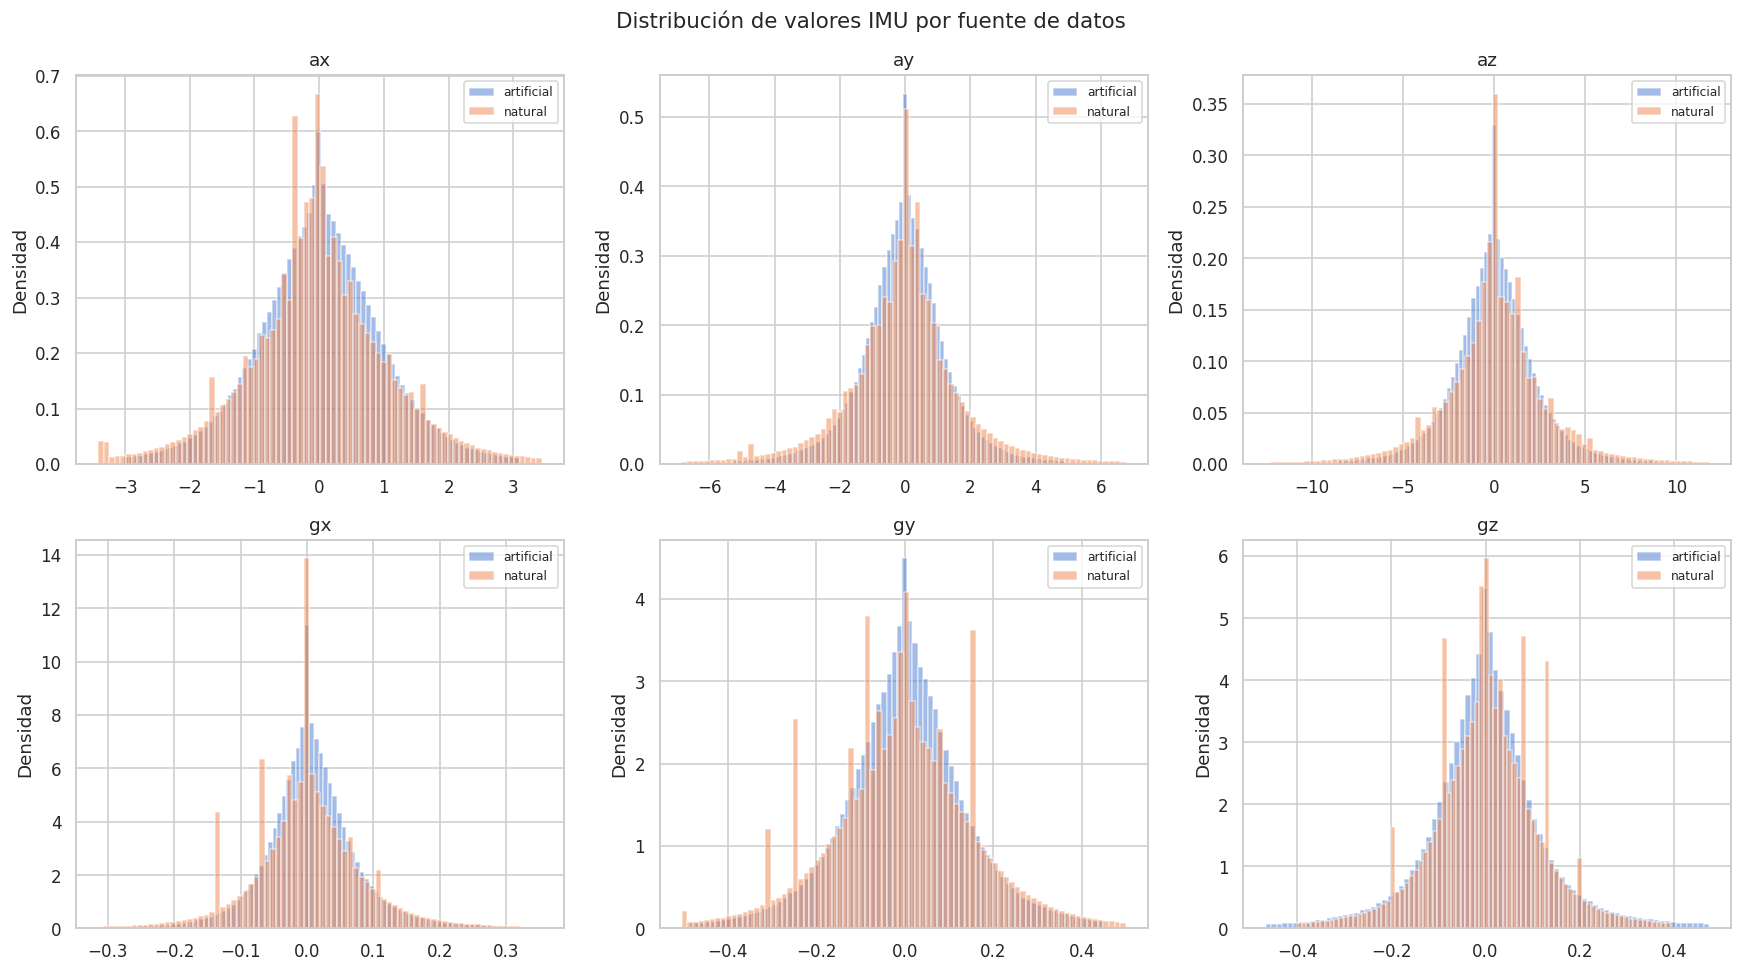

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribución de valores IMU por fuente de datos", fontsize=14)

for i, col in enumerate(IMU_COLS):
    ax = axes[i // 3, i % 3]
    for source_name, group in all_imu.groupby("source"):
        vals = group[col].dropna()
        p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
        vals_clipped = vals[(vals >= p1) & (vals <= p99)]
        ax.hist(vals_clipped, bins=80, alpha=0.5, density=True, label=source_name)
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

## BLOQUE 8 — Magnitud de aceleración y giroscopio

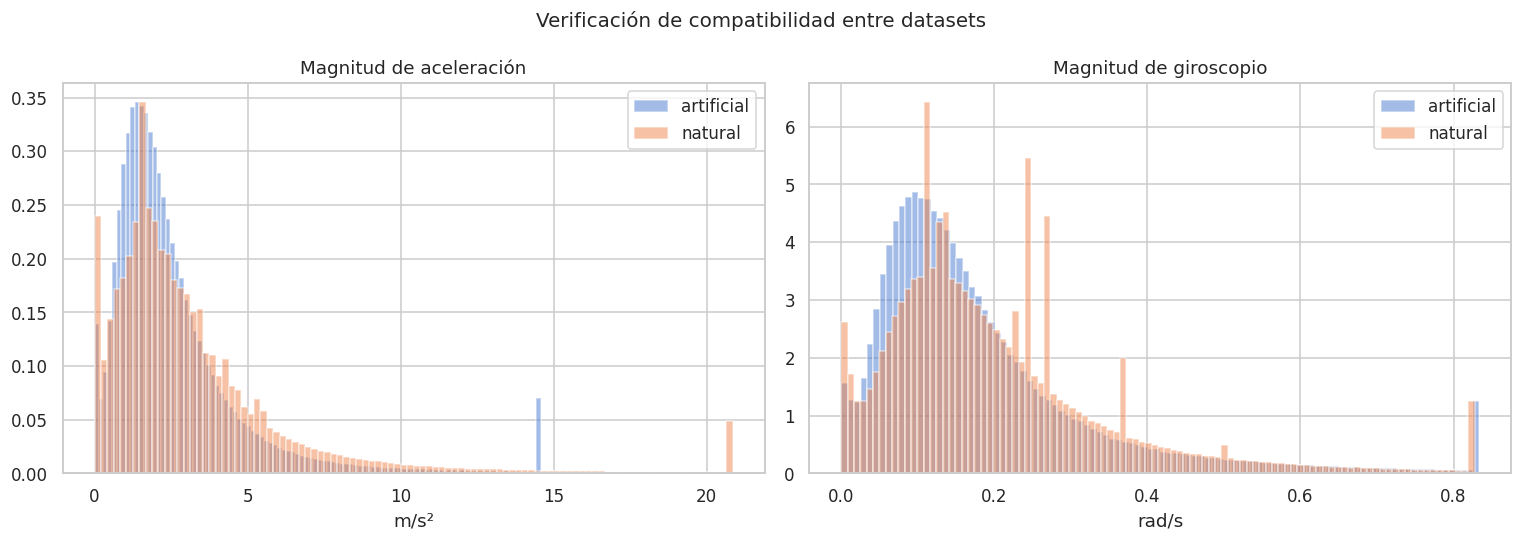

In [ ]:
for col in IMU_COLS:
    all_imu[col] = pd.to_numeric(all_imu[col], errors='coerce')
all_imu.dropna(subset=IMU_COLS, inplace=True)

all_imu["a_mag"] = np.sqrt(all_imu["ax"]**2 + all_imu["ay"]**2 + all_imu["az"]**2)
all_imu["g_mag"] = np.sqrt(all_imu["gx"]**2 + all_imu["gy"]**2 + all_imu["gz"]**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for source_name, group in all_imu.groupby("source"):
    a_clip = group["a_mag"].clip(upper=group["a_mag"].quantile(0.99))
    axes[0].hist(a_clip, bins=100, alpha=0.5, density=True, label=source_name)
axes[0].set_title("Magnitud de aceleración")
axes[0].set_xlabel("m/s²")
axes[0].legend()

for source_name, group in all_imu.groupby("source"):
    g_clip = group["g_mag"].clip(upper=group["g_mag"].quantile(0.99))
    axes[1].hist(g_clip, bins=100, alpha=0.5, density=True, label=source_name)
axes[1].set_title("Magnitud de giroscopio")
axes[1].set_xlabel("rad/s")
axes[1].legend()

plt.suptitle("Verificación de compatibilidad entre datasets", fontsize=13)
plt.tight_layout()
plt.show()

## BLOQUE 8b — Discrepancia de aceleración: Bike&Safe vs Sensor Logger

Los datos reales computados sobre cada fuente muestran lo siguiente:

| Fuente | Mediana ‖a‖ | Media ‖a‖ | Std | Observación |
|---|---|---|---|---|
| **Natural (Sensor Logger)** | 2.38 m/s² | 3.37 m/s² | 4.11 | Aceleración lineal (sin gravedad) |
| **Artificial (Sensor Logger)** | 2.02 m/s² | 2.73 m/s² | 3.17 | Mismo modo, recorridos más controlados |
| **Bike&Safe** | 4.55 m/s² | 6.53 m/s² | 7.11 | Escala diferente, distribución más ancha |

La mediana de Bike&Safe (4.55 m/s²) duplica la de Sensor Logger (~2 m/s²), y su std (7.11) es el doble, lo que indica una distribución mucho más dispersa. Hay dos problemas combinados:

1. **Escala sistemáticamente distinta**: la mediana de Bike&Safe está en el rango de eventos anómalos de Sensor Logger. Lo que Bike&Safe clasifica como un *evento normal* coincide con lo que el modelo asociaría a un *bache o frenada* en Sensor Logger.
2. **Distribución de forma diferente**: la std casi doble y la cola larga de Bike&Safe (media 6.53 vs mediana 4.55) sugieren outliers frecuentes que Sensor Logger no genera en modo lineal.

Bike&Safe tampoco corresponde al modo *total con gravedad* (~9.8 m/s² estático): su mediana de 4.55 ≈ g/2 apunta a una **compensación parcial de gravedad no documentada** o a una orientación de sensor diferente.

El impacto en el modelo es directo: las features estadísticas (RMS, media, percentiles, energía…) de ambos datasets están en escalas numéricamente incompatibles. Mezclarlos hace que el `StandardScaler` compute medias y desviaciones que no representan a ninguna de las dos fuentes correctamente, introduciendo ruido estructural que desestabiliza el entrenamiento.


  Recorridos Naturales (Sensor Logger): n=1,351,679  media=3.37  mediana=2.38  std=4.11  m/s^2
  Recorridos Artificiales (Sensor Logger): n=694,923  media=2.73  mediana=2.02  std=3.17  m/s^2
  Recorridos Bike&Safe: n=269,744  media=6.53  mediana=4.55  std=7.11  m/s^2


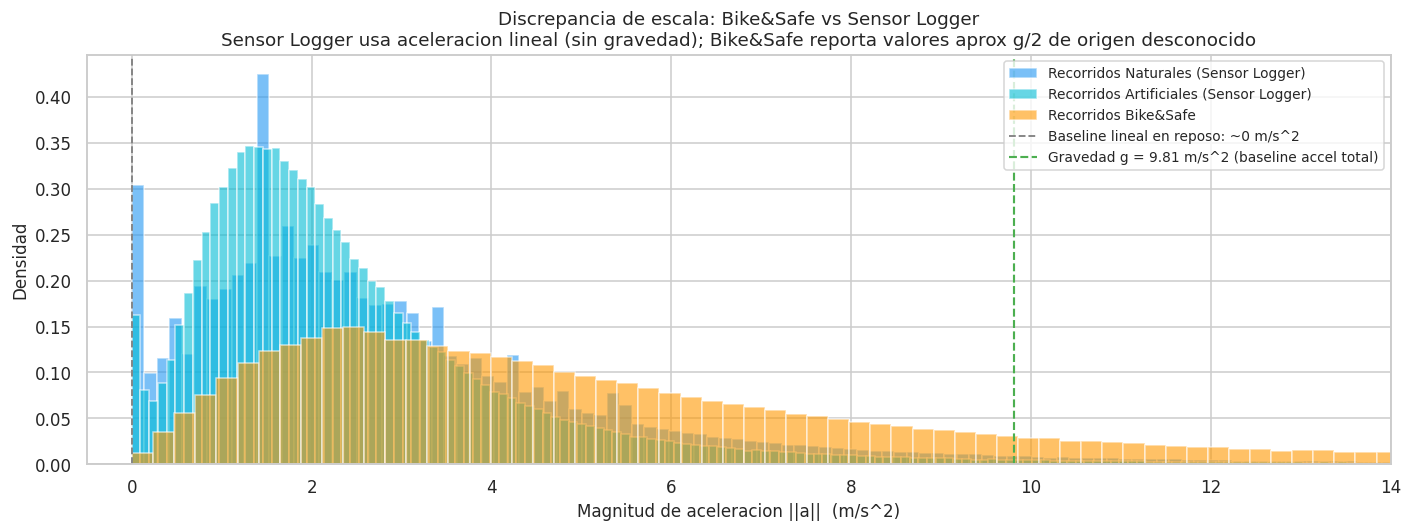


Nota: Bike&Safe no esta disponible (USE_BIKESAFE=False).
La discrepancia observada en el analisis exploratorio previo mostraba:
  Bike&Safe  --  media aprox 6.53 m/s^2 
  Sensor Logger -- media 3.37 m/s^2 


In [ ]:
# ── Compute a_mag from each raw dataframe ─────────────────────────────────────
sources = {
    "Recorridos Naturales (Sensor Logger)":    natural_imu,
    "Recorridos Artificiales (Sensor Logger)": artificial_imu,
    "Recorridos Bike&Safe":                  bikesafe_imu,
}

COLORS = {
    "Recorridos Naturales (Sensor Logger)":    "#2196F3",
    "Recorridos Artificiales (Sensor Logger)": "#00BCD4",
    "Recorridos Bike&Safe":                  "#FF9800",
}

stats = {}
for label, df in sources.items():
    if df.empty:
        print(f"  {label}: sin datos (dataset no cargado)")
        continue
    df = df.copy()
    for col in ["ax", "ay", "az"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    amag = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2).dropna().values
    stats[label] = amag
    print(f"  {label}: n={len(amag):,}  media={amag.mean():.2f}  "
          f"mediana={np.median(amag):.2f}  std={amag.std():.2f}  m/s^2")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

for label, amag in stats.items():
    p99 = np.percentile(amag, 99)
    amag_clip = np.clip(amag, 0, p99)
    ax.hist(amag_clip, bins=150, density=True, alpha=0.60,
            color=COLORS[label], label=label)

ax.axvline(0,    color="gray",    linestyle="--", linewidth=1.2,
           label="Baseline lineal en reposo: ~0 m/s^2")
ax.axvline(9.81, color="#4CAF50", linestyle="--", linewidth=1.4,
           label="Gravedad g = 9.81 m/s^2 (baseline accel total)")

if "Bike&Safe" in stats:
    bs_mean = stats["Bike&Safe"].mean()
    ax.axvline(bs_mean, color="#FF5722", linestyle=":", linewidth=1.8,
               label=f"Media Bike&Safe: {bs_mean:.2f} m/s^2 (anomalia de escala)")

ax.set_xlabel("Magnitud de aceleracion ||a||  (m/s^2)", fontsize=11)
ax.set_ylabel("Densidad", fontsize=11)
ax.set_title("Discrepancia de escala: Bike&Safe vs Sensor Logger\n"
             "Sensor Logger usa aceleracion lineal (sin gravedad); "
             "Bike&Safe reporta valores aprox g/2 de origen desconocido",
             fontsize=12)
ax.set_xlim(-0.5, 14)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

if "Bike&Safe" not in stats:
    print("\nNota: Bike&Safe no esta disponible (USE_BIKESAFE=False).")
    print("La discrepancia observada en el analisis exploratorio previo mostraba:")
    print("  Bike&Safe  --  media aprox 6.53 m/s^2 ")
    print("  Sensor Logger -- media 3.37 m/s^2 ")


## BLOQUE 9 — Series temporales de ejemplo

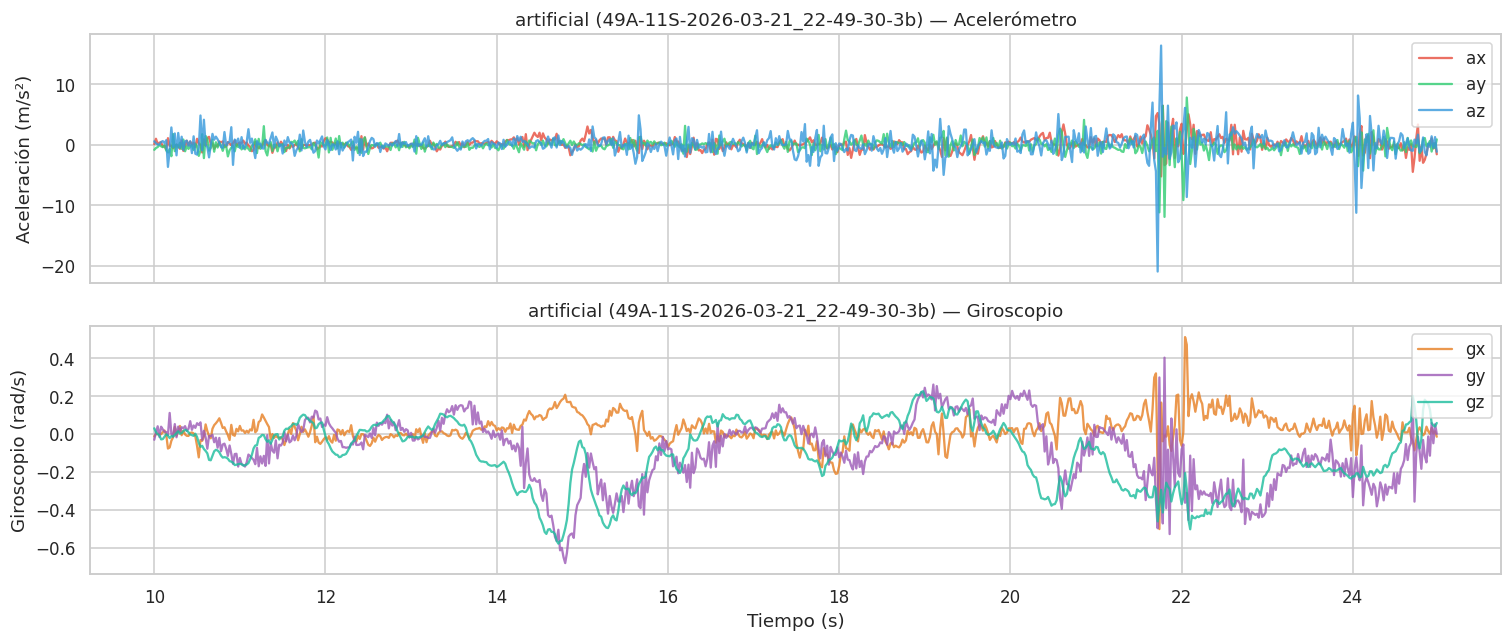

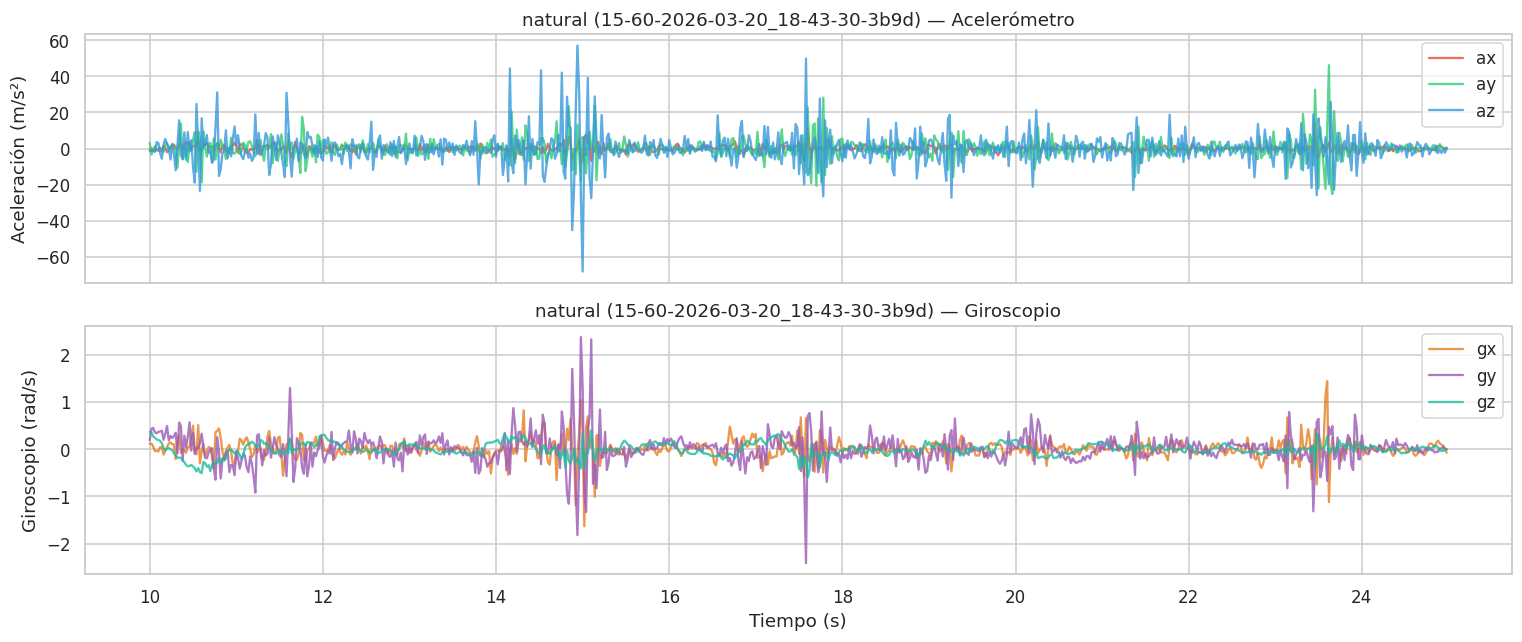

In [ ]:
def plot_ride_segment(imu_df, source_label, start_sec=10, duration_sec=15):
    mask = (imu_df["timestamp"] >= start_sec) & (imu_df["timestamp"] < start_sec + duration_sec)
    segment = imu_df[mask]
    if len(segment) < 10:
        print(f"  Segmento insuficiente para {source_label}")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    t = segment["timestamp"].values

    for col, color in zip(["ax", "ay", "az"], ["#e74c3c", "#2ecc71", "#3498db"]):
        axes[0].plot(t, segment[col].values, label=col, alpha=0.8, color=color)
    axes[0].set_ylabel("Aceleración (m/s²)")
    axes[0].legend(loc="upper right")
    axes[0].set_title(f"{source_label} — Acelerómetro")

    for col, color in zip(["gx", "gy", "gz"], ["#e67e22", "#9b59b6", "#1abc9c"]):
        axes[1].plot(t, segment[col].values, label=col, alpha=0.8, color=color)
    axes[1].set_ylabel("Giroscopio (rad/s)")
    axes[1].set_xlabel("Tiempo (s)")
    axes[1].legend(loc="upper right")
    axes[1].set_title(f"{source_label} — Giroscopio")

    plt.tight_layout()
    plt.show()


for source_name, group in all_imu.groupby("source"):
    first_route = group["route"].iloc[0]
    ride = group[group["route"] == first_route]
    plot_ride_segment(ride, f"{source_name} ({first_route})")

## BLOQUE 10 — Matriz de correlación entre canales IMU

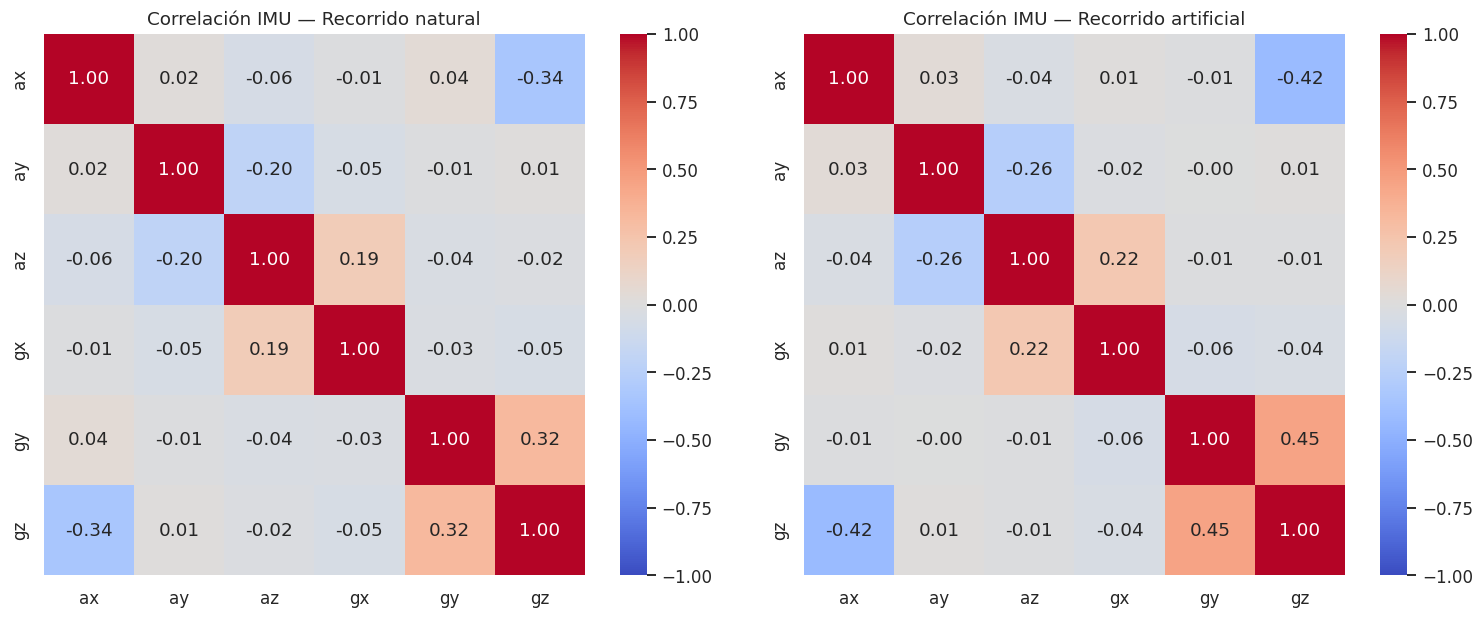

In [ ]:
sources = all_imu["source"].unique()
n_sources = len(sources)
fig, axes = plt.subplots(1, n_sources, figsize=(7 * n_sources, 5.5))
if n_sources == 1:
    axes = [axes]

for ax, source_name in zip(axes, sources):
    corr = all_imu[all_imu["source"] == source_name][IMU_COLS].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(f"Correlación IMU — Recorrido {source_name}")

plt.tight_layout()
plt.show()

---
## BLOQUE 11 — Ventaneo (windowing)

Cada ventana de 128 muestras a 50 Hz cubre **~2.56 segundos** de recorrido, tiempo suficiente para capturar un evento completo (bache, frenado, etc). El stride de 64 genera un solapamiento del 50%.

In [ ]:
def build_windows(imu: pd.DataFrame, win_len=WIN_LEN, stride=STRIDE):
    """Slide a window over the IMU data, returning raw windows and annotation per window.

    The annotation assigned to a window is the last non-null annotation found
    within the window samples (most recent annotated event takes precedence).
    Windows with no annotation get None.
    """
    X = imu[IMU_COLS].values.astype(np.float32)
    ann_vals = imu["annotation"].values if "annotation" in imu.columns else np.full(len(X), None)
    n = X.shape[0]
    windows, window_annotations = [], []
    for s in range(0, n - win_len + 1, stride):
        windows.append(X[s : s + win_len])
        ann_slice = [a for a in ann_vals[s : s + win_len] if pd.notna(a)]
        window_annotations.append(ann_slice[-1] if ann_slice else None)
    if not windows:
        return np.empty((0, win_len, len(IMU_COLS)), dtype=np.float32), []
    return np.stack(windows, axis=0), window_annotations


all_windows = []
meta_list   = []

for source_name, source_group in all_imu.groupby("source"):
    for route_name, route_group in source_group.groupby("route"):
        for lap_name, lap_group in route_group.groupby("lap"):
            wins, ann_list = build_windows(lap_group)
            all_windows.append(wins)
            # Extract GPS arrays for this lap (NaN array if GPS columns absent)
            lat_vals = lap_group["location_latitude"].values if "location_latitude" in lap_group.columns else np.full(len(lap_group), np.nan)
            lon_vals = lap_group["location_longitude"].values if "location_longitude" in lap_group.columns else np.full(len(lap_group), np.nan)
            lap_group_idx = lap_group.index.values  # original positions within lap
            lap_arr_len = len(lap_group)
            for win_i, ann in enumerate(ann_list):
                # Center sample of the window represents the window's GPS position
                center = win_i * STRIDE + WIN_LEN // 2
                meta_list.append({
                    "source":     source_name,
                    "route":      route_name,
                    "lap":        lap_name,
                    "annotation": ann,
                    "lat":        lat_vals[center] if center < lap_arr_len else np.nan,
                    "lon":        lon_vals[center] if center < lap_arr_len else np.nan,
                })

X_all = np.concatenate(all_windows, axis=0)
meta  = pd.DataFrame(meta_list)

print(f"Ventanas totales: {X_all.shape[0]}")
print(f"Forma de cada ventana: {X_all.shape[1:]}  (muestras × canales)")
print(f"\nVentanas por fuente:")
print(meta["source"].value_counts())
print(f"\nAnotaciones por tipo (en ventanas artificiales):")
art_ann = meta[meta["source"] == "artificial"]["annotation"]
print(art_ann.value_counts())

Ventanas totales: 31925
Forma de cada ventana: (128, 6)  (muestras × canales)

Ventanas por fuente:
source
natural       21085
artificial    10840
Name: count, dtype: int64

Anotaciones por tipo (en ventanas artificiales):
annotation
Bache                  304
Esquivada              192
Freno de emergencia    172
Name: count, dtype: int64


## BLOQUE 11b — Data Augmentation de ventanas de eventos (CSE)

Para compensar el desbalance de clases, se generan copias sintéticas de las ventanas que contienen una anotación real de CSE. Se aplican tres transformaciones compatibles con señales IMU:

- **Jitter:** ruido gaussiano de baja amplitud (sigma = 5% de la desviación estándar del canal)
- **Scaling:** escala aleatoria uniforme en [0.9, 1.1] para simular variación de intensidad
- **Time-reverse:** inversión temporal de la ventana (el evento visto en sentido contrario)

Solo se augmentan ventanas del conjunto de **entrenamiento supervisado** (no val, no heurístico) para no contaminar la evaluación.

In [ ]:
# ── Augmentation configuration ────────────────────────────────────────────────
N_AUGMENTS = 3          # synthetic copies per event window
JITTER_SIGMA = 0.05     # Gaussian noise sigma as fraction of each channel's std
SCALE_RANGE  = (0.90, 1.10)

np.random.seed(SEED)


def augment_imu_window(window: np.ndarray) -> list:
    """Return N_AUGMENTS synthetic copies of a single (WIN_LEN, 6) window.

    Applies three complementary transforms to add variety while preserving
    the physical meaning of the signal:
      1. Jitter: additive Gaussian noise (low amplitude)
      2. Scaling: uniform random channel-wise amplitude scaling
      3. Time-reverse: temporal flip (event seen backwards)
    Each copy uses a random combination of transforms.
    """
    aug_windows = []
    ch_std = window.std(axis=0) + 1e-8  # per-channel std for noise scaling
    for _ in range(N_AUGMENTS):
        w = window.copy()
        # Jitter
        w += np.random.normal(0, JITTER_SIGMA * ch_std, w.shape).astype(np.float32)
        # Scaling (50% chance)
        if np.random.rand() > 0.5:
            w *= np.float32(np.random.uniform(*SCALE_RANGE))
        # Time-reverse (33% chance)
        if np.random.rand() > 0.67:
            w = w[::-1].copy()
        aug_windows.append(w)
    return aug_windows


# ── Apply augmentation to CSE-annotated windows ───────────────────────────────
# Augmented windows are tagged with source="artificial_aug" so they can be
# excluded from val at split time if needed.
aug_windows_list = []
aug_meta_list    = []

for i, ann in enumerate(meta["annotation"]):
    if pd.notna(ann) and meta.iloc[i]["source"] == "artificial":
        aug_wins = augment_imu_window(X_all[i])
        for w in aug_wins:
            aug_windows_list.append(w)
            aug_meta_list.append({
                "source":     "artificial_aug",
                "route":      meta.iloc[i]["route"],
                "lap":        meta.iloc[i]["lap"],
                "annotation": ann,
                "orig_idx":   i,  # index of the original window
            })

if aug_windows_list:
    X_aug  = np.stack(aug_windows_list, axis=0)
    meta_aug = pd.DataFrame(aug_meta_list)

    X_all  = np.concatenate([X_all, X_aug], axis=0)
    meta   = pd.concat([meta, meta_aug], ignore_index=True)

    print(f"Augmentation aplicada:")
    print(f"  Ventanas originales con CSE : {len(aug_meta_list) // N_AUGMENTS}")
    print(f"  Copias sintéticas generadas : {len(aug_windows_list)}  ({N_AUGMENTS}x por ventana)")
    print(f"  X_all shape post-aug        : {X_all.shape}")
    print(f"  meta shape  post-aug        : {meta.shape}")
    print(f"\n  Distribución de anotaciones en ventanas augmentadas:")
    print(meta_aug["annotation"].value_counts())
else:
    print("No se encontraron ventanas de CSE para augmentar.")
    meta["orig_idx"] = np.nan

Augmentation aplicada:
  Ventanas originales con CSE : 668
  Copias sintéticas generadas : 2004  (3x por ventana)
  X_all shape post-aug        : (33929, 128, 6)
  meta shape  post-aug        : (33929, 7)

  Distribución de anotaciones en ventanas augmentadas:
annotation
Bache                  912
Esquivada              576
Freno de emergencia    516
Name: count, dtype: int64


## BLOQUE 12 — Feature Engineering

Para la red MLP, cada ventana de 128×6 se resume en un vector de **características estadísticas**.  
Por cada uno de los 6 canales se calculan: media, desviación estándar, mínimo, máximo, rango, RMS (energía), asimetría (skewness) y curtosis.  
Además se computan estadísticas de la magnitud de aceleración y giroscopio.

In [ ]:
def extract_features(window: np.ndarray) -> dict:
    feats = {}
    for i, col in enumerate(IMU_COLS):
        v = window[:, i]
        feats[f"{col}_mean"]  = np.mean(v)
        feats[f"{col}_std"]   = np.std(v)
        feats[f"{col}_min"]   = np.min(v)
        feats[f"{col}_max"]   = np.max(v)
        feats[f"{col}_range"] = np.ptp(v)
        feats[f"{col}_rms"]   = np.sqrt(np.mean(v ** 2))
        feats[f"{col}_skew"]  = float(sp_stats.skew(v))
        feats[f"{col}_kurt"]  = float(sp_stats.kurtosis(v))
        feats[f"{col}_p05"]   = np.percentile(v, 5)
        feats[f"{col}_p95"]   = np.percentile(v, 95)

    ax, ay, az = window[:, 0], window[:, 1], window[:, 2]
    gx, gy, gz = window[:, 3], window[:, 4], window[:, 5]
    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    g_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    for name, mag in [("a_mag", a_mag), ("g_mag", g_mag)]:
        feats[f"{name}_mean"]  = np.mean(mag)
        feats[f"{name}_std"]   = np.std(mag)
        feats[f"{name}_max"]   = np.max(mag)
        feats[f"{name}_range"] = np.ptp(mag)
        feats[f"{name}_rms"]   = np.sqrt(np.mean(mag ** 2))
        feats[f"{name}_p99"]   = np.percentile(mag, 99)

    return feats


print("Extrayendo características estadísticas de cada ventana...")
feat_list = [extract_features(X_all[i]) for i in range(X_all.shape[0])]
feat_df = pd.DataFrame(feat_list)

# Sanitize: skew/kurtosis can produce NaN/Inf for constant-value windows
n_bad = feat_df.isin([np.inf, -np.inf]).sum().sum() + feat_df.isna().sum().sum()
feat_df = feat_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
print(f"Vector de características: {feat_df.shape[1]} features por ventana")
print(f"Total de ventanas: {feat_df.shape[0]}")
print(f"Valores NaN/Inf reemplazados por 0: {n_bad}")
display(feat_df.head())

Extrayendo características estadísticas de cada ventana...


/tmp/ipykernel_98764/2911098285.py:11: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f"{col}_skew"]  = float(sp_stats.skew(v))
/tmp/ipykernel_98764/2911098285.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f"{col}_kurt"]  = float(sp_stats.kurtosis(v))


Vector de características: 72 features por ventana
Total de ventanas: 33929
Valores NaN/Inf reemplazados por 0: 20040


,ax_mean,ax_std,ax_min,ax_max,ax_range,ax_rms,ax_skew,ax_kurt,ax_p05,ax_p95,...,a_mag_max,a_mag_range,a_mag_rms,a_mag_p99,g_mag_mean,g_mag_std,g_mag_max,g_mag_range,g_mag_rms,g_mag_p99
0,0.006191,0.240672,-0.805939,0.673792,1.479731,0.240752,-0.174139,1.099810,-0.392076,0.425262,...,0.809669,0.809669,0.301366,0.761315,0.026904,0.028612,0.123470,0.121415,0.039275,0.120039
1,0.005873,0.138712,-0.460404,0.580152,1.040555,0.138836,0.443261,3.573783,-0.213064,0.221528,...,0.581847,0.577660,0.161287,0.508697,0.014021,0.008681,0.046186,0.044131,0.016491,0.042750
2,0.015472,0.207134,-0.703624,1.499646,2.203270,0.207711,2.715632,20.348604,-0.211512,0.249722,...,1.517957,1.513769,0.237744,0.842931,0.018236,0.019419,0.112339,0.110426,0.026640,0.081757
3,0.005836,0.376770,-1.235769,1.499646,2.735415,0.376815,-0.107174,2.185318,-0.674870,0.518815,...,1.858907,1.825294,0.525487,1.670874,0.037212,0.031549,0.112339,0.110426,0.048786,0.106691
4,-0.121643,0.484408,-1.235769,1.397130,2.632899,0.499448,-0.000925,-0.341611,-0.891922,0.517930,...,1.858907,1.701561,0.803744,1.791973,0.084720,0.072712,0.330985,0.326750,0.111645,0.324280


## BLOQUE 13 — Distribución de features seleccionadas

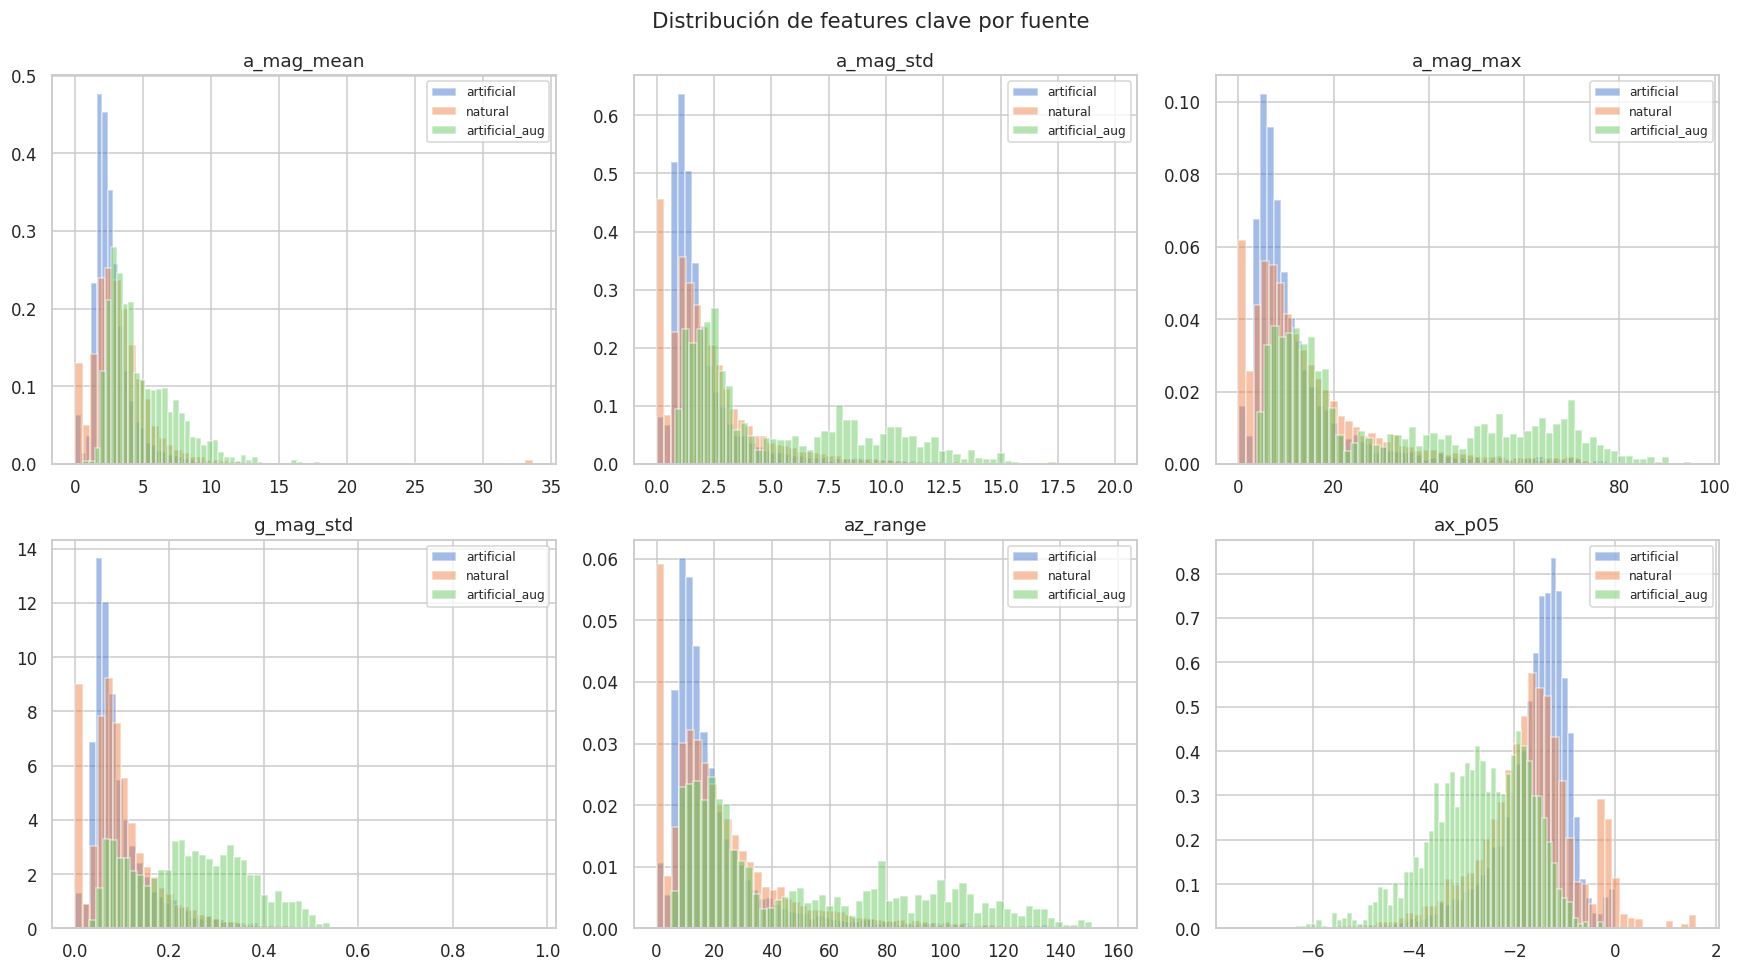

In [ ]:
highlight_feats = ["a_mag_mean", "a_mag_std", "a_mag_max", "g_mag_std", "az_range", "ax_p05"]
highlight_feats = [f for f in highlight_feats if f in feat_df.columns]

combined = feat_df.copy()
combined["source"] = meta["source"].values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribución de features clave por fuente", fontsize=14)

for i, feat_name in enumerate(highlight_feats):
    ax = axes[i // 3, i % 3]
    for src in combined["source"].unique():
        vals = combined[combined["source"] == src][feat_name]
        ax.hist(vals, bins=60, alpha=0.5, density=True, label=src)
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## BLOQUE 14 — Etiquetado por severidad (3 clases)

Se asigna una etiqueta a cada ventana según su severity_score y bump_score, calibrados con los umbrales del conjunto de entrenamiento. La misma estrategia usada en el notebook CNN.

In [ ]:
def compute_scores(feats: dict) -> tuple:
    ax_p05     = feats.get("ax_p05",     0)
    a_mag_p99  = feats.get("a_mag_p99",  0)
    g_mag_p99  = feats.get("g_mag_p99",  0)
    g_mag_std  = feats.get("g_mag_std",  0)
    az_max     = feats.get("az_max",     0)

    severity_score = abs(ax_p05) + a_mag_p99 + g_mag_p99 + g_mag_std
    bump_score     = abs(az_max)
    return float(severity_score), float(bump_score)


scores = np.array([compute_scores(feat_list[i]) for i in range(len(feat_list))])
feat_df["severity_score"] = scores[:, 0]
feat_df["bump_score"]     = scores[:, 1]

# Rates: fraction of windows labeled as each class.
# Lower values = stricter thresholds = fewer anomalies detected.
TARGET_SEVERE_RATE = 0.08
TARGET_BUMP_RATE   = 0.18

bikesafe_mask  = (meta["source"] == "bikesafe").values
natural_mask   = (meta["source"] == "natural").values
art_mask       = (meta["source"] == "artificial").values
art_aug_mask   = (meta["source"] == "artificial_aug").values  # augmented copies


# Split by RIDES (not random windows) to prevent data leakage
# from the 50% overlapping windows.
nat_routes = meta[natural_mask]["route"].unique().tolist()
np.random.seed(SEED)
np.random.shuffle(nat_routes)
split_idx = max(1, int(len(nat_routes) * 0.8))
train_rides_h = nat_routes[:split_idx]
val_rides_h   = nat_routes[split_idx:]
train_mask_h = natural_mask & meta["route"].isin(train_rides_h).values
val_mask_h   = natural_mask & meta["route"].isin(val_rides_h).values
calibration_indices = np.where(train_mask_h)[0]
print(f"Heuristic split (natural rides):")
print(f"  Train rides ({len(train_rides_h)}): {train_rides_h}")
print(f"  Val rides   ({len(val_rides_h)}):   {val_rides_h}")
print(f"  Train windows: {train_mask_h.sum()}, Val windows: {val_mask_h.sum()}")

# ── Supervised split: time-segmented split within each ride ───────────────────
# Problem with whole-ride split: 7 rides with a 60x length range means one
# partition can be dominated by the longest ride (_86-2, ~58 min = 47% of data).
# Solution: within each artificial ride, the first 70% of windows go to train
# and the last 30% go to val. A gap of WIN_LEN samples at the boundary prevents
# any overlap leakage (since stride < win_len, adjacent windows share samples).
SUPERVISED_TRAIN_FRAC = 0.70
SUPERVISED_SPLIT_GAP  = WIN_LEN  # samples to skip at the boundary

train_mask_s = np.zeros(len(meta), dtype=bool)
val_mask_s   = np.zeros(len(meta), dtype=bool)

# Augmented windows always go to train (they are synthetic; never used for eval)
train_mask_s[art_aug_mask] = True

art_routes   = meta[art_mask]["route"].unique().tolist()
route_stats  = []

for route_name in art_routes:
    ride_idx = np.where(art_mask & (meta["route"] == route_name).values)[0]
    n_wins = len(ride_idx)
    if n_wins == 0:
        continue

    # Number of windows that map to the first 70% of the ride
    # Leave a gap of WIN_LEN samples (= 1 full window) at the boundary
    n_train = max(1, int(n_wins * SUPERVISED_TRAIN_FRAC))
    # The gap removes one extra window at the boundary to prevent leakage
    gap_wins = max(1, SUPERVISED_SPLIT_GAP // STRIDE)
    n_val_start = min(n_train + gap_wins, n_wins)

    n_val = n_wins - n_val_start

    train_idx = ride_idx[:n_train]
    val_idx   = ride_idx[n_val_start:]

    train_mask_s[train_idx] = True
    val_mask_s[val_idx]     = True

    route_stats.append({
        "route": route_name, "total": n_wins,
        "train": len(train_idx), "gap": n_val_start - n_train, "val": n_val,
    })

print(f"\nSupervised split (time-segmented within each ride):")
print(f"  Split ratio: first {SUPERVISED_TRAIN_FRAC*100:.0f}% train, last {(1-SUPERVISED_TRAIN_FRAC)*100:.0f}% val")
print(f"  Boundary gap: {SUPERVISED_SPLIT_GAP // STRIDE} windows skipped at each ride boundary")
print(f"\n  {'Route':<38} {'Total':>6} {'Train':>6} {'Gap':>5} {'Val':>6}")
print(f"  {'-'*64}")
for r in route_stats:
    print(f"  {r['route']:<38} {r['total']:>6} {r['train']:>6} {r['gap']:>5} {r['val']:>6}")
print(f"\n  TOTAL  train windows: {train_mask_s.sum()}, val windows: {val_mask_s.sum()}")

# ── Calibrate heuristic thresholds on natural train split ─────────────────────
if len(calibration_indices) > 0:
    sev_th  = float(np.percentile(feat_df.loc[calibration_indices, "severity_score"], 100 * (1 - TARGET_SEVERE_RATE)))
    bump_th = float(np.percentile(feat_df.loc[calibration_indices, "bump_score"],     100 * (1 - TARGET_BUMP_RATE)))
else:
    sev_th, bump_th = 0.0, 0.0
    print("AVISO: no hay datos de calibración para los umbrales heurísticos.")

print(f"\nUmbrales calibrados (heurístico):")
print(f"  severity_threshold = {sev_th:.4f}  (top {TARGET_SEVERE_RATE*100:.0f}%)")
print(f"  bump_threshold     = {bump_th:.4f}  (top {TARGET_BUMP_RATE*100:.0f}%)")

# ── Heuristic labels (3 classes) ──────────────────────────────────────────────
N = len(feat_df)
labels_heuristic = np.zeros(N, dtype=np.int32)
labels_heuristic[feat_df["severity_score"].values >= sev_th] = 2
labels_heuristic[(labels_heuristic == 0) & (feat_df["bump_score"].values >= bump_th)] = 1
meta["label_heuristic"] = labels_heuristic

# ── Supervised labels (4 classes) ─────────────────────────────────────────────
labels_supervised = np.zeros(N, dtype=np.int32)
for i, ann in enumerate(meta["annotation"]):
    if pd.notna(ann) and ann in ANNOTATION_TO_LABEL:
        labels_supervised[i] = ANNOTATION_TO_LABEL[ann]
meta["label_supervised"] = labels_supervised

print(f"\nDistribución heurística (global):")
h_counts = pd.Series(labels_heuristic).map(LABELS_3).value_counts()
print(h_counts)
print(f"\nDistribución supervisada (ventanas artificiales):")
s_counts = pd.Series(labels_supervised[art_mask]).map(LABELS_4).value_counts()
print(s_counts)

Heuristic split (natural rides):
  Train rides (19): ['6C-38-2026-03-20_18-30-16-3b9d', 'Parque_Virgilio_Barco-2026-03-', '15-60-2026-03-20_18-43-30-3b9d', '_15-49-2026-03-20_19-09-01-3b9', 'Avenida_Calle_24-2026-03-20_21', '9-15-2026-03-20_19-25-12-3b9d3', 'H_mboldt_Park-2026-03-20_20-52', '42-51-2026-03-20_21-44-44-3b9d', '_58N-19-2026-02-28_15-37-37-3b', '48_-_50_Sur-2026-03-10_18-10-4', '45-3-2026-03-20_19-57-00-3b9d3', 'Bosa-2026-03-23_18-15-26-3b9d3', 'Interior_154-2026-03-17_15-04-', '48-01-2026-03-04_18-56-03-3b9d', '48-01-2026-03-17_20-54-32-3b9d', '_62-38-2026-03-20_21-23-20-3b9', 'Salida_a_Mosquera_marca_de_ca_', '_58N-19-2026-02-25_19-29-52-3b', '_72L-55-2026-03-17_16-56-54-3b']
  Val rides   (5):   ['59-63-2026-03-20_20-17-51-3b9d', '9-2-2026-03-20_21-21-49-3b9d32', 'Interior_154-2026-02-24_19-25-', '_39A-33-2026-03-12_15-13-37-3b', '50-2-2026-03-20_19-39-42-3b9d3']
  Train windows: 18627, Val windows: 2458

Supervised split (time-segmented within each ride):
  Split ratio

## BLOQUE 15 — Distribución de scores y umbrales

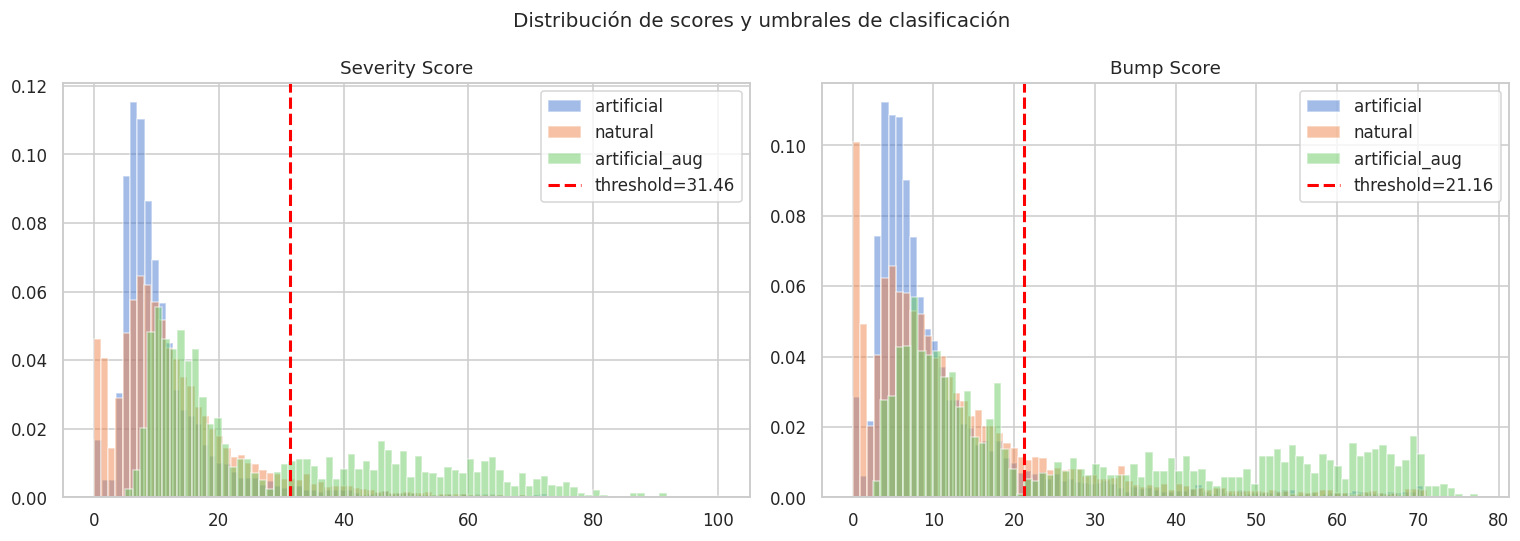

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for src in meta["source"].unique():
    mask_src = (meta["source"] == src).values
    axes[0].hist(feat_df.loc[mask_src, "severity_score"], bins=80, alpha=0.5, density=True, label=src)
axes[0].axvline(sev_th, color="red", ls="--", lw=2, label=f"threshold={sev_th:.2f}")
axes[0].set_title("Severity Score")
axes[0].legend()

for src in meta["source"].unique():
    mask_src = (meta["source"] == src).values
    axes[1].hist(feat_df.loc[mask_src, "bump_score"], bins=80, alpha=0.5, density=True, label=src)
axes[1].axvline(bump_th, color="red", ls="--", lw=2, label=f"threshold={bump_th:.2f}")
axes[1].set_title("Bump Score")
axes[1].legend()

plt.suptitle("Distribución de scores y umbrales de clasificación", fontsize=13)
plt.tight_layout()
plt.show()

## BLOQUE 16 — Split train / val / test y normalización

In [ ]:
meta["split_heuristic"]  = "unused"
meta["split_supervised"] = "unused"
meta.loc[train_mask_h, "split_heuristic"]  = "train"
meta.loc[val_mask_h,   "split_heuristic"]  = "val"
meta.loc[train_mask_s, "split_supervised"] = "train"
meta.loc[val_mask_s,   "split_supervised"] = "val"

X_feats = feat_df.drop(columns=["severity_score", "bump_score"], errors="ignore").values.astype(np.float32)

def prepare_split(X_feats, labels, train_mask, val_mask, scaler=None):
    """Scale features and return train/val arrays. Fits scaler on train if not provided."""
    X_tr_raw = X_feats[train_mask]
    y_tr     = labels[train_mask]
    X_vl_raw = X_feats[val_mask]
    y_vl     = labels[val_mask]

    if scaler is None:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
    else:
        X_tr = scaler.transform(X_tr_raw)

    X_vl = scaler.transform(X_vl_raw) if len(X_vl_raw) > 0 else np.empty((0, X_tr.shape[1]))

    for name, arr in [("X_train", X_tr), ("X_val", X_vl)]:
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        if name == "X_train":
            X_tr = arr
        else:
            X_vl = arr

    return X_tr, y_tr, X_vl, y_vl, scaler

# ── Heuristic split (natural rides, 3-class labels) ───────────────────────────
X_train_h, y_train_h, X_val_h, y_val_h, scaler_h = prepare_split(
    X_feats, labels_heuristic, train_mask_h, val_mask_h
)
print("=" * 60)
print("HEURISTIC MODEL — data split")
print(f"X_train_h : {X_train_h.shape}   y_train_h : {y_train_h.shape}")
print(f"X_val_h   : {X_val_h.shape}   y_val_h   : {y_val_h.shape}")
print("\nDistribución de clases (heuristic train):")
for u, c in zip(*np.unique(y_train_h, return_counts=True)):
    print(f"  {LABELS_3[u]}: {c} ({c/len(y_train_h)*100:.1f}%)")
print("\nDistribución de clases (heuristic val):")
for u, c in zip(*np.unique(y_val_h, return_counts=True)):
    print(f"  {LABELS_3[u]}: {c} ({c/len(y_val_h)*100:.1f}%)")

# ── Supervised split (artificial rides + augmented, 4-class labels) ───────────
print("\n" + "=" * 60)
print("SUPERVISED MODEL — data split")
if train_mask_s.any():
    X_train_s, y_train_s, X_val_s, y_val_s, scaler_s = prepare_split(
        X_feats, labels_supervised, train_mask_s, val_mask_s
    )
    print(f"X_train_s (pre-SMOTE) : {X_train_s.shape}   y_train_s : {y_train_s.shape}")
    print(f"X_val_s               : {X_val_s.shape}   y_val_s   : {y_val_s.shape}")
    print("\nDistribución de clases (supervised train, pre-SMOTE):")
    for u, c in zip(*np.unique(y_train_s, return_counts=True)):
        print(f"  {LABELS_4[u]}: {c} ({c/len(y_train_s)*100:.1f}%)")

    # ── SMOTE oversampling ─────────────────────────────────────────────────────
    # Apply SMOTE to the 4-class supervised training set to further balance CSE
    # classes. Use k_neighbors=min(3, minority_count-1) to handle small classes.
    # SMOTE operates at the feature level, complementing signal-level augmentation.
    try:
        from imblearn.over_sampling import SMOTE
        class_counts = np.bincount(y_train_s, minlength=len(LABELS_4))
        minority_count = int(class_counts[class_counts > 0].min())
        k_neighbors = max(1, min(3, minority_count - 1))
        if minority_count >= 2:
            sm = SMOTE(k_neighbors=k_neighbors, random_state=SEED)
            X_train_s, y_train_s = sm.fit_resample(X_train_s, y_train_s)
            print(f"\nSMOTE aplicado (k_neighbors={k_neighbors}):")
            print(f"  X_train_s (post-SMOTE) : {X_train_s.shape}")
            print("\nDistribución de clases (supervised train, post-SMOTE):")
            for u, c in zip(*np.unique(y_train_s, return_counts=True)):
                print(f"  {LABELS_4[u]}: {c} ({c/len(y_train_s)*100:.1f}%)")
        else:
            print(f"\nAVISO: clase minoritaria tiene {minority_count} muestra(s). SMOTE omitido.")
    except ImportError:
        print("\nAVISO: imbalanced-learn no instalado. Ejecuta: pip install imbalanced-learn")
        print("  Continuando sin SMOTE.")

    print("\nDistribución de clases (supervised val):")
    for u, c in zip(*np.unique(y_val_s, return_counts=True)):
        print(f"  {LABELS_4[u]}: {c} ({c/len(y_val_s)*100:.1f}%)")
else:
    X_train_s = X_val_s = np.empty((0, X_feats.shape[1]))
    y_train_s = y_val_s = np.array([], dtype=np.int32)
    scaler_s  = scaler_h
    print("AVISO: sin datos artificiales para el modelo supervisado.")

# ── Backward-compatibility aliases ────────────────────────────────────────────
# Keep single-model variable names pointing to the heuristic split
X_train, y_train, X_val, y_val, scaler = X_train_h, y_train_h, X_val_h, y_val_h, scaler_h

HEURISTIC MODEL — data split
X_train_h : (18627, 72)   y_train_h : (18627,)
X_val_h   : (2458, 72)   y_val_h   : (2458,)

Distribución de clases (heuristic train):
  normal: 15262 (81.9%)
  bache: 1874 (10.1%)
  severo: 1491 (8.0%)

Distribución de clases (heuristic val):
  normal: 2015 (82.0%)
  bache: 234 (9.5%)
  severo: 209 (8.5%)

SUPERVISED MODEL — data split
X_train_s (pre-SMOTE) : (9587, 72)   y_train_s : (9587,)
X_val_s               : (3235, 72)   y_val_s   : (3235,)

Distribución de clases (supervised train, pre-SMOTE):
  normal: 7110 (74.2%)
  bache: 1131 (11.8%)
  esquivada: 712 (7.4%)
  freno: 634 (6.6%)

SMOTE aplicado (k_neighbors=3):
  X_train_s (post-SMOTE) : (28440, 72)

Distribución de clases (supervised train, post-SMOTE):
  normal: 7110 (25.0%)
  bache: 7110 (25.0%)
  esquivada: 7110 (25.0%)
  freno: 7110 (25.0%)

Distribución de clases (supervised val):
  normal: 3041 (94.0%)
  bache: 84 (2.6%)
  esquivada: 56 (1.7%)
  freno: 54 (1.7%)


---
# PROPOSED SHALLOW NEURAL NETWORK BASED APPROACH

Se propone un **Perceptrón Multicapa (MLP)** con dos capas ocultas. A diferencia de la CNN que procesa ventanas crudas de 128×6, el MLP recibe un vector plano de características estadísticas extraídas de cada ventana.

**Arquitectura:**  
`Input(n_features) → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.2) → Dense(3, Softmax)`

**Justificación:**  
- 2 capas ocultas: red superficial adecuada para features pre-calculadas
- ReLU: evita gradientes que desaparecen, eficiente computacionalmente
- Dropout: regularización para prevenir sobreajuste
- Softmax: salida probabilística para 3 clases

---

## BLOQUE 17 — Construcción del modelo MLP

In [ ]:
def build_mlp(n_features: int, n_classes: int = 3, name: str = "mlp") -> keras.Model:
    inp = keras.Input(shape=(n_features,), name=f"{name}_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out, name=name)


n_features = X_train_h.shape[1]

# Model A: Heuristic MLP — 3 classes (normal / bache / severo)
mlp_heuristic = build_mlp(n_features, n_classes=3, name="mlp_heuristic")
print("Model A — Heuristic MLP (3 classes):")
mlp_heuristic.summary()

# Model B: Supervised MLP — 4 classes (normal / bache / esquivada / freno)
mlp_supervised = build_mlp(n_features, n_classes=4, name="mlp_supervised")
print("\nModel B — Supervised MLP (4 classes):")
mlp_supervised.summary()

# Backward-compatibility alias
mlp_model = mlp_heuristic

Model A — Heuristic MLP (3 classes):


Model: "mlp_heuristic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mlp_heuristic_input             │ (None, 72)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,795 (69.51 KB)

 Trainable params: 17,795 (69.51 KB)

...

Model: "mlp_supervised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mlp_supervised_input            │ (None, 72)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,860 (69.77 KB)

 Trainable params: 17,860 (69.77 KB)

 Non-trainable params: 0 (0.00 B)

## BLOQUE 18 — Entrenamiento

In [ ]:
LR = 1e-3
EPOCHS = 100
BATCH_SIZE = 256


def train_mlp(model, X_tr, y_tr, X_vl, y_vl, label_map, model_label="Model"):
    """Compile and train a single MLP. Returns the Keras History object."""
    classes_present = np.unique(y_tr)
    weights = compute_class_weight(class_weight="balanced", classes=classes_present, y=y_tr)
    cw = dict(zip(classes_present.tolist(), weights.tolist()))
    print(f"\n{model_label} — class weights:")
    print("  " + ", ".join(f"{label_map[k]}: {v:.3f}" for k, v in cw.items()))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
        jit_compile=False,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ]

    val_data = (X_vl, y_vl) if len(X_vl) > 0 else None
    hist = model.fit(
        X_tr, y_tr,
        validation_data=val_data,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=cw,
        verbose=1,
    )
    return hist


# ── Train Model A: Heuristic (natural rides, 3 classes) ───────────────────────
print("=" * 60)
print("TRAINING MODEL A — Heuristic MLP (3 classes, natural rides)")
print("=" * 60)
history_h = train_mlp(mlp_heuristic, X_train_h, y_train_h, X_val_h, y_val_h,
                       LABELS_3, "Model A (Heuristic)")

# ── Train Model B: Supervised (artificial rides, 4 classes) ───────────────────
print("\n" + "=" * 60)
print("TRAINING MODEL B — Supervised MLP (4 classes, artificial rides)")
print("=" * 60)
if len(X_train_s) > 0:
    history_s = train_mlp(mlp_supervised, X_train_s, y_train_s, X_val_s, y_val_s,
                           LABELS_4, "Model B (Supervised)")
else:
    history_s = None
    print("AVISO: sin datos de entrenamiento supervisado — salteando Model B.")

# Backward-compatibility alias
history = history_h

TRAINING MODEL A — Heuristic MLP (3 classes, natural rides)

Model A (Heuristic) — class weights:
  normal: 0.407, bache: 3.313, severo: 4.164
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8107 - loss: 0.5546 - val_accuracy: 0.8832 - val_loss: 0.2711 - learning_rate: 0.0010
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9115 - loss: 0.3311 - val_accuracy: 0.9085 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9289 - loss: 0.2572 - val_accuracy: 0.9353 - val_loss: 0.1524 - learning_rate: 0.0010
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9377 - loss: 0.2222 - val_accuracy: 0.9426 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9435 - loss: 0.2033 - val_accuracy: 0.9528 - val_loss: 0.1174 - learning_rate: 0.0010
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9493 - loss: 0.1869 - val_accuracy: 0

---
# PRELIMINARY RESULTS AND PERFORMANCE EVALUATION
---

## BLOQUE 19 — Curvas de entrenamiento (loss y accuracy)

Model A — Heuristic MLP:


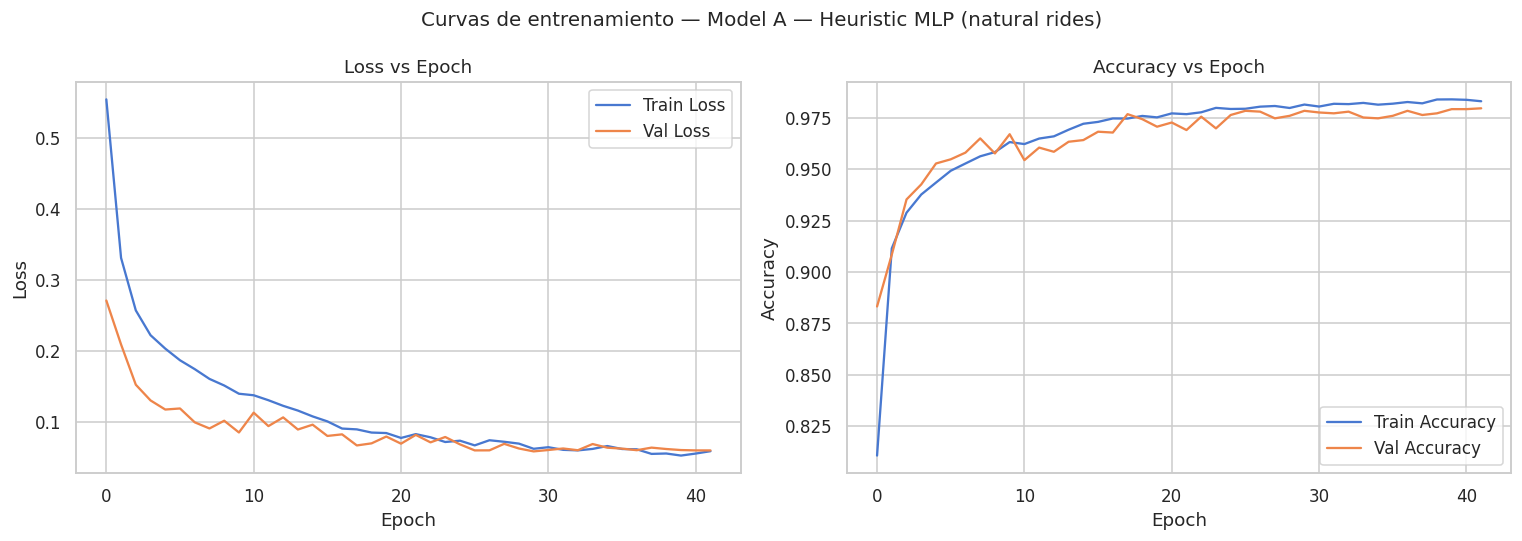

Final train loss: 0.0587, val loss: 0.0598, gap: 0.0011
  El modelo parece estar aprendiendo adecuadamente.

Model B — Supervised MLP:


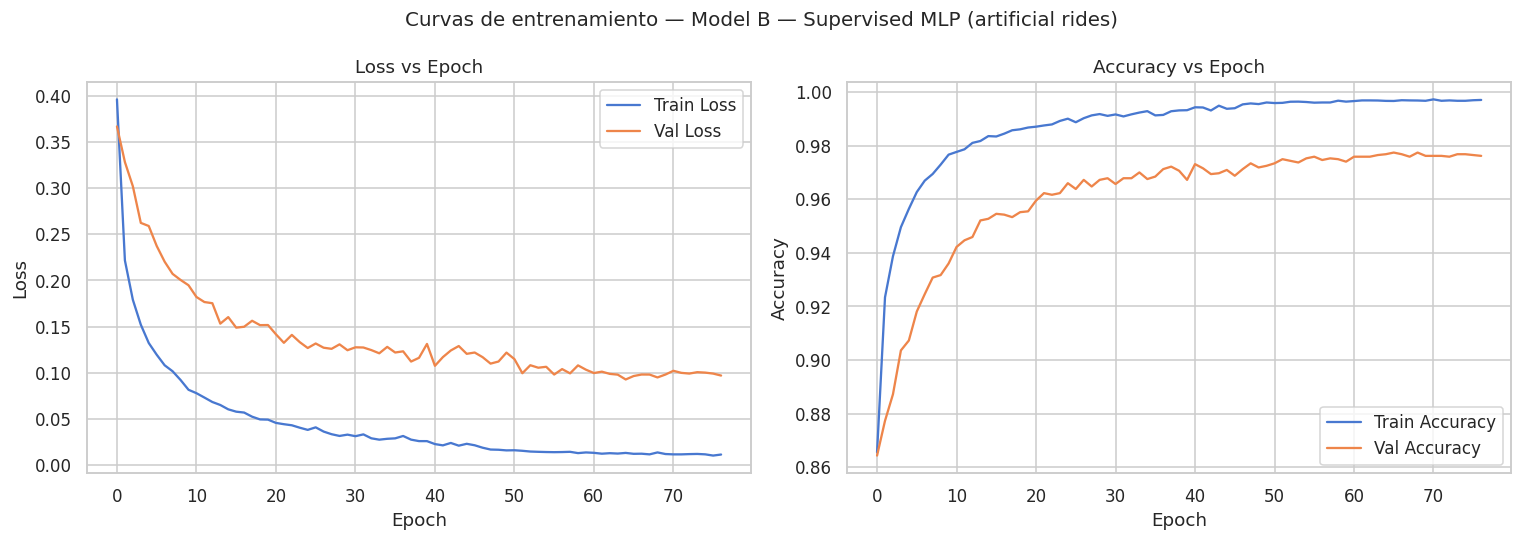

Final train loss: 0.0115, val loss: 0.0970, gap: 0.0855
  El modelo parece estar aprendiendo adecuadamente.


In [ ]:
def plot_training_curves(hist, title="MLP"):
    if hist is None:
        print(f"No hay historial de entrenamiento para {title}.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist.history["loss"], label="Train Loss")
    if "val_loss" in hist.history:
        axes[0].plot(hist.history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(hist.history["accuracy"], label="Train Accuracy")
    if "val_accuracy" in hist.history:
        axes[1].plot(hist.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.suptitle(f"Curvas de entrenamiento — {title}", fontsize=13)
    plt.tight_layout()
    plt.show()

    if "val_loss" in hist.history:
        final_train_loss = hist.history["loss"][-1]
        final_val_loss   = hist.history["val_loss"][-1]
        gap = final_val_loss - final_train_loss
        print(f"Final train loss: {final_train_loss:.4f}, val loss: {final_val_loss:.4f}, gap: {gap:.4f}")
        if gap > 0.3:
            print("  Posible OVERFITTING.")
        elif final_train_loss > 0.8:
            print("  Posible UNDERFITTING.")
        else:
            print("  El modelo parece estar aprendiendo adecuadamente.")


print("Model A — Heuristic MLP:")
plot_training_curves(history_h, "Model A — Heuristic MLP (natural rides)")

print("\nModel B — Supervised MLP:")
plot_training_curves(history_s, "Model B — Supervised MLP (artificial rides)")

## BLOQUE 20 — Métricas de clasificación (Validation set)


EVALUACIÓN — Validation Heuristic (natural rides)
Accuracy : 0.9784
F1 Macro : 0.9432

Classification Report (argmax):
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      2015
       bache       0.83      0.97      0.90       234
      severo       0.97      0.91      0.94       209

    accuracy                           0.98      2458
   macro avg       0.93      0.96      0.94      2458
weighted avg       0.98      0.98      0.98      2458



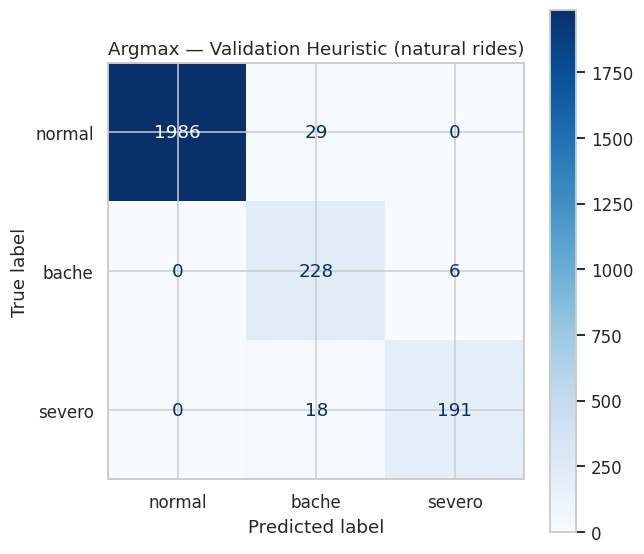


EVALUACIÓN — Validation Supervised (artificial rides, held-out)
Accuracy : 0.9768
F1 Macro : 0.8824

Classification Report (argmax):
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99      3041
       bache       0.66      1.00      0.80        84
   esquivada       0.80      1.00      0.89        56
       freno       0.75      1.00      0.86        54

    accuracy                           0.98      3235
   macro avg       0.80      0.99      0.88      3235
weighted avg       0.98      0.98      0.98      3235


Buscando umbrales óptimos (grid search 10^3 combinaciones)…

Umbrales óptimos encontrados: {'normal': np.float64(1.0), 'bache': np.float64(0.644), 'esquivada': np.float64(0.822), 'freno': np.float64(1.0)}
Accuracy (tuned) : 0.9768  (Δ +0.0000)
F1 Macro (tuned) : 0.8824  (Δ +0.0000)

Classification Report (threshold-tuned):
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99      3

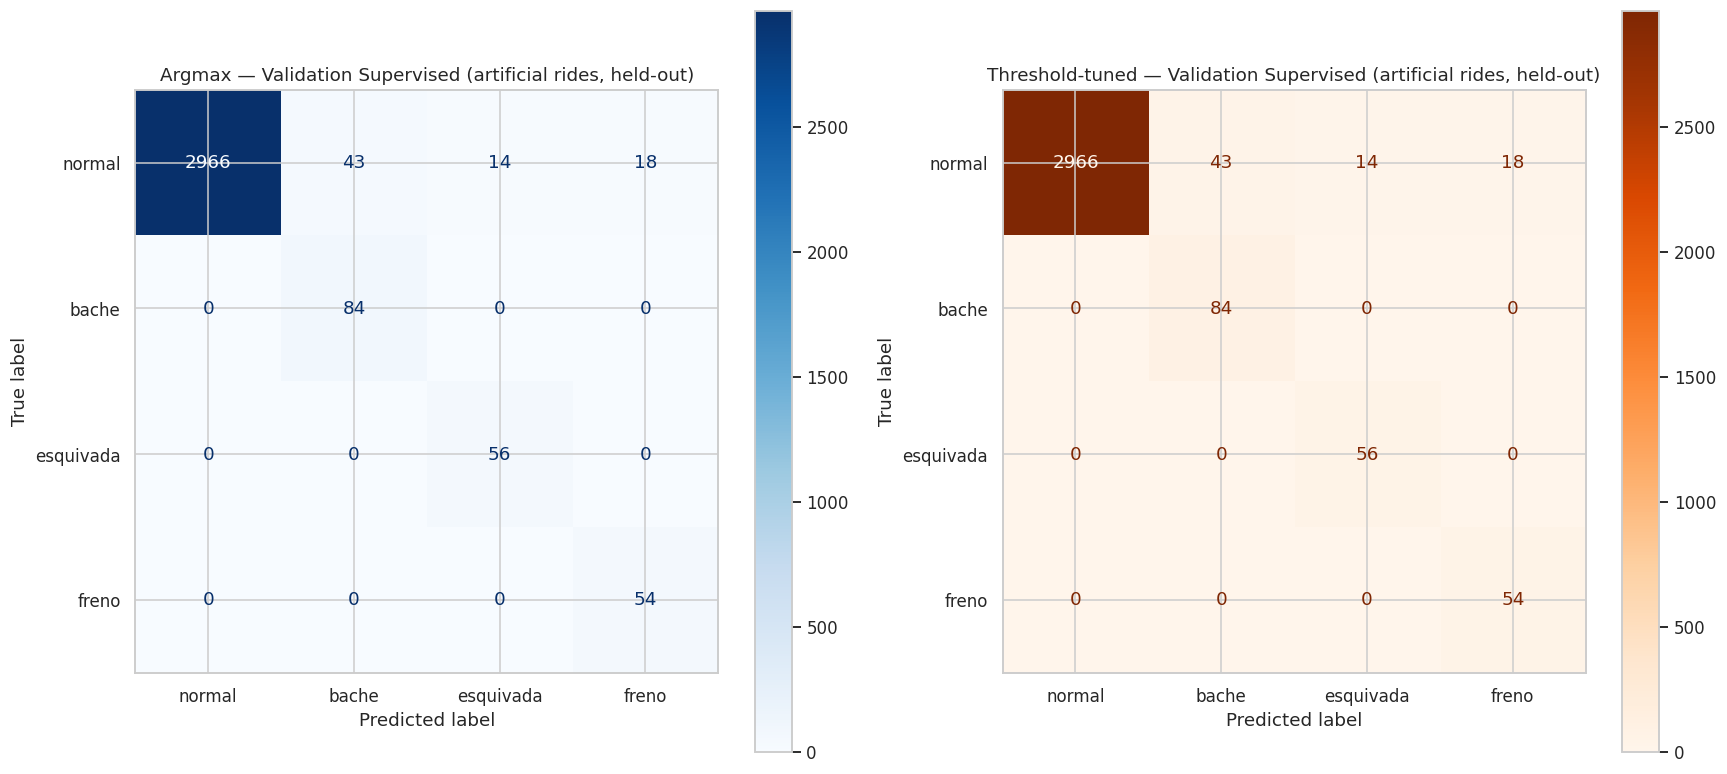

In [ ]:
def tune_thresholds(proba: np.ndarray, y_true: np.ndarray,
                    n_classes: int, grid_steps: int = 10) -> np.ndarray:
    """Grid-search per-class probability thresholds to maximise macro F1.

    The decision rule is:  y_pred = argmax(proba / thresholds)
    Dividing by a lower threshold amplifies that class's probability, making
    the model more eager to predict it.  Class 0 (normal) is kept at 1.0
    while CSE-class thresholds are swept from 0.2 to 1.0.

    Returns the best thresholds array (shape: n_classes).
    """
    from itertools import product
    candidates = np.linspace(0.20, 1.0, grid_steps)
    best_f1, best_thr = -1.0, np.ones(n_classes)
    # Search over CSE classes (indices 1..n_classes-1); keep normal fixed at 1.0
    for combo in product(candidates, repeat=n_classes - 1):
        thr = np.array([1.0] + list(combo))
        y_pred = np.argmax(proba / thr, axis=1)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr.copy()
    return best_thr


def evaluate_and_report(model, X, y, set_name="Validation", label_map=None,
                        tune_thr: bool = False):
    """Evaluate a model and print accuracy, F1, classification report, and confusion matrix.

    If tune_thr=True, also runs threshold tuning (grid search on this same set)
    and reports a second confusion matrix with the tuned thresholds.  Note: tuning
    on the val set is optimistic; use a separate test set for unbiased evaluation.
    """
    if label_map is None:
        label_map = LABELS_3
    n_classes = len(label_map)
    class_ids = sorted(label_map.keys())

    if len(X) == 0:
        print(f"\n{set_name}: sin datos para evaluar.")
        return None

    y_pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc      = accuracy_score(y, y_pred)
    f1_macro = f1_score(y, y_pred, average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"EVALUACIÓN — {set_name}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Macro : {f1_macro:.4f}")
    print(f"\nClassification Report (argmax):")
    print(classification_report(
        y, y_pred,
        target_names=[label_map[i] for i in class_ids],
        labels=class_ids,
        zero_division=0,
    ))

    n_cols = 2 if tune_thr and n_classes > 2 else 1
    fig, axes = plt.subplots(1, n_cols,
                             figsize=(max(6, n_classes * 2) * n_cols,
                                      max(5, n_classes * 1.8)))
    if n_cols == 1:
        axes = [axes]

    cm = confusion_matrix(y, y_pred, labels=class_ids)
    disp = ConfusionMatrixDisplay(cm, display_labels=[label_map[i] for i in class_ids])
    disp.plot(ax=axes[0], cmap="Blues", values_format="d")
    axes[0].set_title(f"Argmax — {set_name}")

    result = {"accuracy": acc, "f1_macro": f1_macro,
              "y_pred": y_pred, "best_thresholds": None}

    # ── Threshold tuning ───────────────────────────────────────────────────────
    if tune_thr and n_classes > 2:
        print(f"\nBuscando umbrales óptimos (grid search {10}^{n_classes-1} combinaciones)…")
        best_thr = tune_thresholds(y_pred_proba, y, n_classes)
        y_pred_thr = np.argmax(y_pred_proba / best_thr, axis=1)
        acc_thr  = accuracy_score(y, y_pred_thr)
        f1_thr   = f1_score(y, y_pred_thr, average="macro", zero_division=0)

        print(f"\nUmbrales óptimos encontrados: {dict(zip([label_map[i] for i in class_ids], best_thr.round(3)))}")
        print(f"Accuracy (tuned) : {acc_thr:.4f}  (Δ {acc_thr - acc:+.4f})")
        print(f"F1 Macro (tuned) : {f1_thr:.4f}  (Δ {f1_thr - f1_macro:+.4f})")
        print(f"\nClassification Report (threshold-tuned):")
        print(classification_report(
            y, y_pred_thr,
            target_names=[label_map[i] for i in class_ids],
            labels=class_ids,
            zero_division=0,
        ))

        cm_thr = confusion_matrix(y, y_pred_thr, labels=class_ids)
        disp2 = ConfusionMatrixDisplay(cm_thr, display_labels=[label_map[i] for i in class_ids])
        disp2.plot(ax=axes[1], cmap="Oranges", values_format="d")
        axes[1].set_title(f"Threshold-tuned — {set_name}")

        result["best_thresholds"] = best_thr
        result["f1_macro_tuned"]  = f1_thr
        result["y_pred_tuned"]    = y_pred_thr

    plt.tight_layout()
    plt.show()

    return result


# ── Evaluate Model A (Heuristic) ──────────────────────────────────────────────
val_label_h = "Validation Heuristic (natural rides)"
val_results_h = evaluate_and_report(mlp_heuristic, X_val_h, y_val_h, val_label_h, LABELS_3)

# ── Evaluate Model B (Supervised) — with threshold tuning ─────────────────────
val_results_s = evaluate_and_report(
    mlp_supervised, X_val_s, y_val_s,
    "Validation Supervised (artificial rides, held-out)",
    LABELS_4, tune_thr=True,
) if len(X_val_s) > 0 else None

# Backward-compatibility aliases
val_results = val_results_h

## BLOQUE 21 — Evaluación en Train (sanity check) y análisis de predicciones


EVALUACIÓN — Train set — Heuristic (sanity check)
Accuracy : 0.9884
F1 Macro : 0.9765

Classification Report (argmax):
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99     15262
       bache       0.90      0.99      0.95      1874
      severo       0.99      1.00      0.99      1491

    accuracy                           0.99     18627
   macro avg       0.96      0.99      0.98     18627
weighted avg       0.99      0.99      0.99     18627



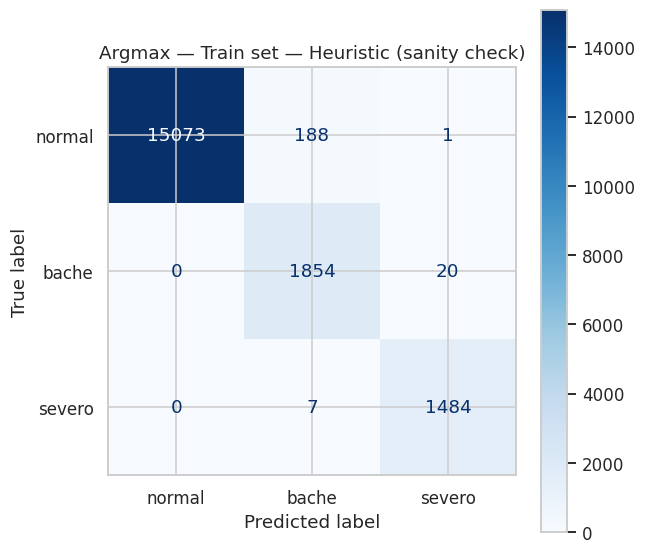


ANÁLISIS DE PREDICCIONES EN VALIDACIÓN HEURÍSTICA
Predicciones del modelo heurístico:
  normal: 1986 ventanas (80.8%)
  bache: 275 ventanas (11.2%)
  severo: 197 ventanas (8.0%)

Tiempo estimado de anomalías: 604s (10.1 min)


In [ ]:
train_results = evaluate_and_report(mlp_heuristic, X_train_h, y_train_h,
                                    "Train set — Heuristic (sanity check)", LABELS_3)

print("\n" + "="*60)
print("ANÁLISIS DE PREDICCIONES EN VALIDACIÓN HEURÍSTICA")
print("="*60)
if val_results_h:
    y_val_pred_h = val_results_h["y_pred"]
    unique_pred, counts_pred = np.unique(y_val_pred_h, return_counts=True)
    print("Predicciones del modelo heurístico:")
    for u, c in zip(unique_pred, counts_pred):
        print(f"  {LABELS_3[u]}: {c} ventanas ({c/len(y_val_pred_h)*100:.1f}%)")

    n_anomalies = np.sum(y_val_pred_h > 0)
    total_time_anomaly = n_anomalies * (WIN_LEN / TARGET_HZ) * (STRIDE / WIN_LEN)
    print(f"\nTiempo estimado de anomalías: {total_time_anomaly:.0f}s ({total_time_anomaly/60:.1f} min)")

In [ ]:
# ── Resumen global del dataset para el informe ────────────────────────────────
TARGET_HZ_REPORT = 50

summary_rows = []

for label, df, csv_dir in [
    ("artificial", artificial_imu,  ARTIFICIAL_DATA_DIR),
    ("natural",    natural_imu,  NATURAL_DATA_DIR),
]:
    n_samples  = len(df)
    n_routes   = df["route"].nunique() if "route" in df.columns else 0
    dur_s      = n_samples / TARGET_HZ_REPORT          # seconds at 50 Hz
    dur_min    = dur_s / 60
    dur_h      = dur_s / 3600
    n_ann      = int(df["annotation"].notna().sum()) if "annotation" in df.columns else 0
    n_ann_types = df["annotation"].nunique() if "annotation" in df.columns and n_ann > 0 else 0
    has_gps    = "location_latitude" in df.columns and df["location_latitude"].notna().any()
    gps_cover  = df["location_latitude"].notna().mean() * 100 if has_gps else 0.0
    summary_rows.append({
        "Tipo":            label,
        "Recorridos":      n_routes,
        "Muestras (50Hz)": f"{n_samples:,}",
        "Duración (min)":  f"{dur_min:.1f}",
        "Duración (h)":    f"{dur_h:.2f}",
        "Muestras anotadas": f"{n_ann:,}",
        "Tipos de evento":  n_ann_types,
        "Cobertura GPS %":  f"{gps_cover:.1f}",
    })

# ── Combined totals ───────────────────────────────────────────────────────────
combined = pd.concat([artificial_imu, natural_imu], ignore_index=True)
total_samples = len(combined)
total_routes  = artificial_imu["route"].nunique() + natural_imu["route"].nunique()
total_dur_h   = total_samples / TARGET_HZ_REPORT / 3600
total_ann     = int(combined["annotation"].notna().sum()) if "annotation" in combined.columns else 0

import pandas as pd
summary_df = pd.DataFrame(summary_rows)

print("="*64)
print("RESUMEN GLOBAL DEL DATASET")
print("="*64)
display(summary_df.set_index("Tipo"))

print()
print(f"TOTALES COMBINADOS (artificial + natural)")
print(f"  Recorridos totales  : {total_routes}")
print(f"  Muestras totales    : {total_samples:,}")
print(f"  Duración total      : {total_dur_h:.2f} h  ({total_dur_h*60:.1f} min)")
print(f"  Muestras anotadas   : {total_ann:,}")
if "annotation" in combined.columns and total_ann > 0:
    print()
    print("  Anotaciones por tipo:")
    ann_counts = combined["annotation"].value_counts()
    ann_counts["Total"] = ann_counts.sum()
    for evt, cnt in ann_counts.items():
        print(f"    {evt:<30} {cnt:>6}")


RESUMEN GLOBAL DEL DATASET


,Recorridos,Muestras (50Hz),Duración (min),Duración (h),Muestras anotadas,Tipos de evento,Cobertura GPS %
Tipo,,,,,,,
artificial,11,"694,923",231.6,3.86,335,3,100.0
natural,24,"1,351,679",450.6,7.51,0,0,100.0



TOTALES COMBINADOS (artificial + natural)
  Recorridos totales  : 35
  Muestras totales    : 2,046,602
  Duración total      : 11.37 h  (682.2 min)
  Muestras anotadas   : 335

  Anotaciones por tipo:
    Bache                             152
    Esquivada                          96
    Freno de emergencia                87
    Total                             335


## BLOQUE 22 — Tabla resumen comparativa

In [ ]:
summary_rows = []

if train_results:
    summary_rows.append({
        "Modelo": "A — Heuristic (3 clases)",
        "Conjunto": "Train (natural)",
        "Muestras": len(X_train_h),
        "Accuracy": f"{train_results['accuracy']:.4f}",
        "F1 Macro": f"{train_results['f1_macro']:.4f}",
    })

if val_results_h:
    val_label_short = "Bike&Safe (val)"
    summary_rows.append({
        "Modelo": "A — Heuristic (3 clases)",
        "Conjunto": val_label_short,
        "Muestras": len(X_val_h),
        "Accuracy": f"{val_results_h['accuracy']:.4f}",
        "F1 Macro": f"{val_results_h['f1_macro']:.4f}",
    })

if val_results_s:
    summary_rows.append({
        "Modelo": "B — Supervised (4 clases)",
        "Conjunto": "Artificial rides (val hold-out)",
        "Muestras": len(X_val_s),
        "Accuracy": f"{val_results_s['accuracy']:.4f}",
        "F1 Macro": f"{val_results_s['f1_macro']:.4f}",
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("\nResumen de rendimiento — ambos modelos MLP:")
    display(summary_df)
else:
    print("No hay resultados para mostrar.")


Resumen de rendimiento — ambos modelos MLP:


,Modelo,Conjunto,Muestras,Accuracy,F1 Macro
0,A — Heuristic (3 clases),Train (natural),18627,0.9884,0.9765
1,A — Heuristic (3 clases),Bike&Safe (val),2458,0.9784,0.9432
2,B — Supervised (4 clases),Artificial rides (val hold-out),3235,0.9768,0.8824


## BLOQUE 22b — Comparación directa: Heurístico vs Supervisado en rides artificiales

Ambos modelos se evalúan sobre el **mismo conjunto de validación artificial** (rides retenidos).

Para comparar en una escala común (3 clases), las predicciones del modelo supervisado se colapsan:
- `esquivada` (2) → `severo` (2)
- `freno` (3) → `severo` (2)
- `bache` (1) → `bache` (1)
- `normal` (0) → `normal` (0)

COMPARACIÓN — Heurístico vs Supervisado en rides artificiales (held-out)
Ventanas totales   : 3235
Modelo                                     Accuracy   F1 Macro
--------------------------------------------------------------
A — Heuristic MLP (natural trains)           0.8547     0.3379
B — Supervised MLP (artificial trains)       0.9768     0.8856


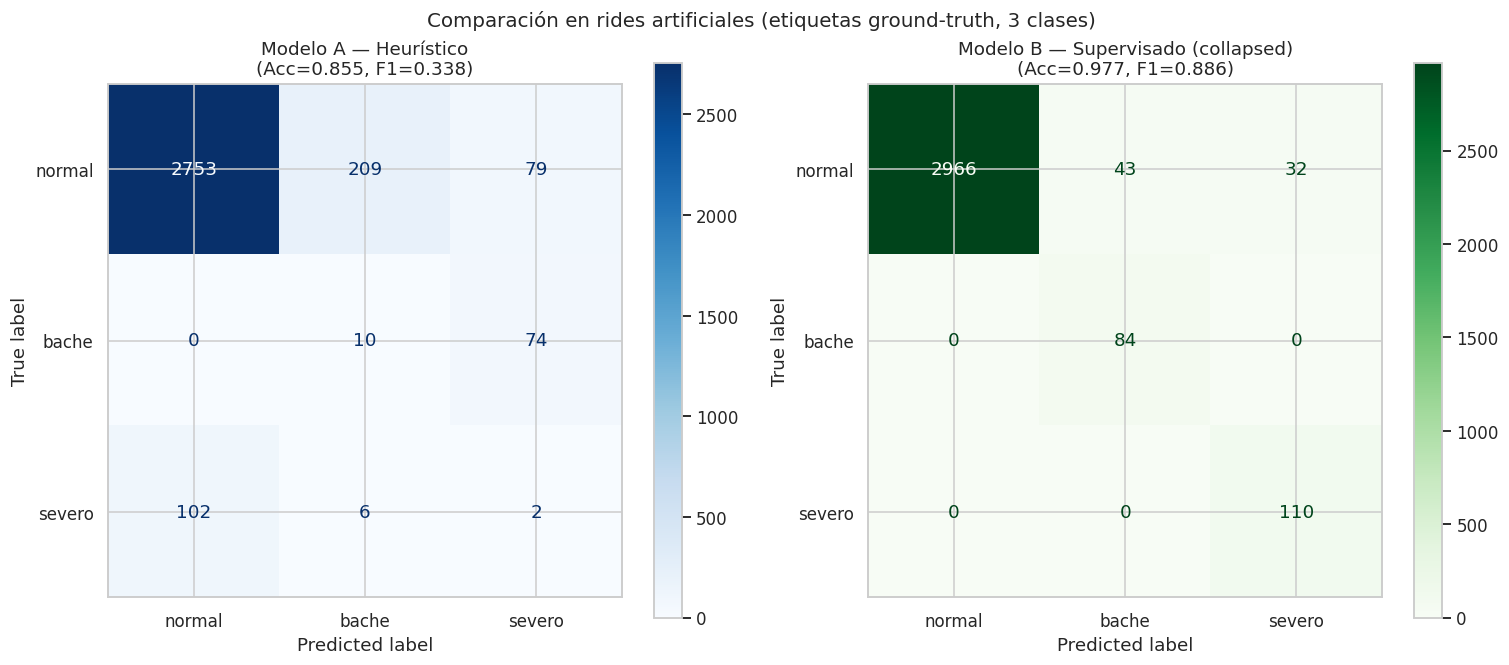

In [ ]:
def collapse_4_to_3(y_4class):
    """Map 4-class supervised predictions to the 3-class heuristic scheme.

    Mapping: normal(0)→0, bache(1)→1, esquivada(2)→2, freno(3)→2
    """
    y_3 = y_4class.copy()
    y_3[y_3 == 3] = 2  # freno → severo
    return y_3


if len(X_val_s) > 0:
    # Ground-truth labels on the artificial val set (3-class: collapse esquivada/freno → severo)
    y_val_art_3 = collapse_4_to_3(y_val_s.copy())

    # Model A predictions on the artificial val set (needs re-scaling with scaler_h)
    X_val_art_h_scaled = np.nan_to_num(scaler_h.transform(X_feats[val_mask_s]), nan=0.0)
    y_pred_h_on_art    = np.argmax(mlp_heuristic.predict(X_val_art_h_scaled, verbose=0), axis=1)

    # Model B predictions (already scaled with scaler_s), collapsed to 3 classes
    y_pred_s_on_art_4  = np.argmax(mlp_supervised.predict(X_val_s, verbose=0), axis=1)
    y_pred_s_on_art_3  = collapse_4_to_3(y_pred_s_on_art_4)

    acc_h = accuracy_score(y_val_art_3, y_pred_h_on_art)
    f1_h  = f1_score(y_val_art_3, y_pred_h_on_art, average="macro", zero_division=0)
    acc_s = accuracy_score(y_val_art_3, y_pred_s_on_art_3)
    f1_s  = f1_score(y_val_art_3, y_pred_s_on_art_3, average="macro", zero_division=0)

    print("=" * 70)
    print("COMPARACIÓN — Heurístico vs Supervisado en rides artificiales (held-out)")
    # print(f"Rides de validación: {val_art_rides}")
    print(f"Ventanas totales   : {len(y_val_art_3)}")
    print("=" * 70)
    print(f"{'Modelo':<40} {'Accuracy':>10} {'F1 Macro':>10}")
    print("-" * 62)
    print(f"{'A — Heuristic MLP (natural trains)':<40} {acc_h:>10.4f} {f1_h:>10.4f}")
    print(f"{'B — Supervised MLP (artificial trains)':<40} {acc_s:>10.4f} {f1_s:>10.4f}")
    print("=" * 70)

    # Side-by-side confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    display_labels = [LABELS_3[i] for i in [0, 1, 2]]

    cm_h = confusion_matrix(y_val_art_3, y_pred_h_on_art, labels=[0, 1, 2])
    ConfusionMatrixDisplay(cm_h, display_labels=display_labels).plot(
        ax=axes[0], cmap="Blues", values_format="d"
    )
    axes[0].set_title(f"Modelo A — Heurístico\n(Acc={acc_h:.3f}, F1={f1_h:.3f})")

    cm_s = confusion_matrix(y_val_art_3, y_pred_s_on_art_3, labels=[0, 1, 2])
    ConfusionMatrixDisplay(cm_s, display_labels=display_labels).plot(
        ax=axes[1], cmap="Greens", values_format="d"
    )
    axes[1].set_title(f"Modelo B — Supervisado (collapsed)\n(Acc={acc_s:.3f}, F1={f1_s:.3f})")

    plt.suptitle("Comparación en rides artificiales (etiquetas ground-truth, 3 clases)",
                 fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos artificiales de validación — omitiendo comparación.")

## BLOQUE 23 — Diagnóstico de overfitting / underfitting

In [ ]:
def diagnose_model(hist, model, model_label="Modelo"):
    if hist is None:
        print(f"{model_label}: sin historial.")
        return
    print(f"\nDIAGNÓSTICO — {model_label}")
    print("=" * 60)

    train_loss_final = hist.history["loss"][-1]
    train_acc_final  = hist.history["accuracy"][-1]
    print(f"Train Loss final    : {train_loss_final:.4f}")
    print(f"Train Accuracy final: {train_acc_final:.4f}")

    if "val_loss" in hist.history:
        val_loss_final = hist.history["val_loss"][-1]
        val_acc_final  = hist.history["val_accuracy"][-1]
        print(f"Val Loss final      : {val_loss_final:.4f}")
        print(f"Val Accuracy final  : {val_acc_final:.4f}")

        loss_gap = val_loss_final - train_loss_final
        acc_gap  = train_acc_final - val_acc_final

        if loss_gap > 0.3 or acc_gap > 0.10:
            print("DIAGNÓSTICO: OVERFITTING")
        elif train_loss_final > 0.8 and train_acc_final < 0.65:
            print("DIAGNÓSTICO: UNDERFITTING")
        else:
            print("DIAGNÓSTICO: AJUSTE ADECUADO")
    else:
        print("Sin datos de validación.")

    print(f"Epochs entrenados   : {len(hist.history['loss'])}")
    print(f"Total de parámetros : {model.count_params():,}")


diagnose_model(history_h, mlp_heuristic, "Model A — Heuristic MLP")
diagnose_model(history_s, mlp_supervised, "Model B — Supervised MLP")


DIAGNÓSTICO — Model A — Heuristic MLP
Train Loss final    : 0.0587
Train Accuracy final: 0.9831
Val Loss final      : 0.0598
Val Accuracy final  : 0.9797
DIAGNÓSTICO: AJUSTE ADECUADO
Epochs entrenados   : 42
Total de parámetros : 17,795

DIAGNÓSTICO — Model B — Supervised MLP
Train Loss final    : 0.0115
Train Accuracy final: 0.9971
Val Loss final      : 0.0970
Val Accuracy final  : 0.9762
DIAGNÓSTICO: AJUSTE ADECUADO
Epochs entrenados   : 77
Total de parámetros : 17,860


## BLOQUE 24 — Guardado de artefactos

In [ ]:
import pickle

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature matrices and labels (MLP inputs) ──────────────────────────────────
np.save(OUT_DIR / "X_train_h.npy", X_train_h)
np.save(OUT_DIR / "y_train_h.npy", y_train_h)
np.save(OUT_DIR / "X_val_h.npy",   X_val_h)
np.save(OUT_DIR / "y_val_h.npy",   y_val_h)

if len(X_train_s) > 0:
    np.save(OUT_DIR / "X_train_s.npy", X_train_s)
    np.save(OUT_DIR / "y_train_s.npy", y_train_s)
    np.save(OUT_DIR / "X_val_s.npy",   X_val_s)
    np.save(OUT_DIR / "y_val_s.npy",   y_val_s)

feat_df.to_csv(OUT_DIR / "window_features_mlp.csv", index=False)

# ── CNN preparation: raw windows + meta + split masks ─────────────────────────
# X_all shape: (N_windows, WIN_LEN, N_channels) — ready for 1D-CNN input
# meta has columns: source, route, lap, annotation, label_heuristic,
#                   label_supervised, split_heuristic, split_supervised
# The masks let the CNN notebook use the exact same train/val partition as
# the MLP for a fair, apple-to-apple comparison.
np.save(OUT_DIR / "X_all_windows.npy",   X_all)           # raw IMU windows
np.save(OUT_DIR / "train_mask_s.npy",    train_mask_s)    # supervised train mask
np.save(OUT_DIR / "val_mask_s.npy",      val_mask_s)      # supervised val mask
np.save(OUT_DIR / "train_mask_h.npy",    train_mask_h)    # heuristic train mask
np.save(OUT_DIR / "val_mask_h.npy",      val_mask_h)      # heuristic val mask
meta.to_csv(OUT_DIR / "meta_mlp.csv", index=False)        # includes both label cols

print(f"CNN prep saved:")
print(f"  X_all_windows : {X_all.shape}  (N × {WIN_LEN} × {len(IMU_COLS)})")
print(f"  train_mask_s  : {train_mask_s.sum()} windows")
print(f"  val_mask_s    : {val_mask_s.sum()} windows")

# ── Threshold artifacts (for supervised model deployment) ─────────────────────
if val_results_s and val_results_s.get("best_thresholds") is not None:
    np.save(OUT_DIR / "best_thresholds_s.npy", val_results_s["best_thresholds"])
    print(f"\nBest thresholds saved: {val_results_s['best_thresholds'].round(3)}")

# ── Scalers ───────────────────────────────────────────────────────────────────
with open(OUT_DIR / "scaler_h.pkl", "wb") as f:
    pickle.dump(scaler_h, f)
with open(OUT_DIR / "scaler_s.pkl", "wb") as f:
    pickle.dump(scaler_s, f)

# ── Models ────────────────────────────────────────────────────────────────────
mlp_heuristic.save(MODEL_DIR / "mlp_heuristic.keras")
if len(X_train_s) > 0:
    mlp_supervised.save(MODEL_DIR / "mlp_supervised.keras")

print(f"\nArtefactos guardados en: {OUT_DIR} y {MODEL_DIR}")
print(f"\nArchivos en {OUT_DIR}:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
print(f"\nArchivos en {MODEL_DIR}:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

CNN prep saved:
  X_all_windows : (33929, 128, 6)  (N × 128 × 6)
  train_mask_s  : 9587 windows
  val_mask_s    : 3235 windows

Best thresholds saved: [1.    0.644 0.822 1.   ]

Artefactos guardados en: /home/cramirez/code/CyclingSafety/features y /home/cramirez/code/CyclingSafety/models/mlp

Archivos en /home/cramirez/code/CyclingSafety/features:
  X_all_windows.npy  (101787.1 KB)
  X_train_h.npy  (5239.0 KB)
  X_train_mlp.npy  (3716.8 KB)
  X_train_s.npy  (7998.9 KB)
  X_val_h.npy  (691.4 KB)
  X_val_mlp.npy  (2262.5 KB)
  X_val_s.npy  (910.0 KB)
  best_thresholds_s.npy  (0.2 KB)
  map_predictions.csv  (1774.2 KB)
  meta_mlp.csv  (2842.0 KB)
  scaler_h.pkl  (2.1 KB)
  scaler_s.pkl  (2.1 KB)
  train_mask_h.npy  (33.3 KB)
  train_mask_s.npy  (33.3 KB)
  val_mask_h.npy  (33.3 KB)
  val_mask_s.npy  (33.3 KB)
  window_features_mlp.csv  (29793.2 KB)
  y_train_h.npy  (72.9 KB)
  y_train_mlp.npy  (51.7 KB)
  y_train_s.npy  (111.2 KB)
  y_val_h.npy  (9.7 KB)
  y_val_mlp.npy  (31.5 KB)
  y_val

## BLOQUE 25 — Preparación de predicciones con GPS para mapeo

Filtra las ventanas de **recorridos naturales** que tienen coordenadas GPS válidas, corre el modelo supervisado (Model B) sobre ellas y construye un `map_df` con columnas:
- `lat`, `lon` — coordenadas del centro de la ventana
- `route` — nombre del recorrido
- `pred_class` — clase predicha (0=normal, 1=bache, 2=esquivada, 3=freno)
- `pred_label` — etiqueta legible
- `confidence` — probabilidad máxima
- `severity_score` — puntuación heurística de severidad

In [ ]:
import os
import folium
from folium.plugins import HeatMap

# ── Supervised label map ───────────────────────────────────────────────────────
SUPERVISED_LABEL_MAP = {0: "normal", 1: "bache", 2: "esquivada", 3: "freno"}

# ── Filter to natural rides with valid GPS ─────────────────────────────────────
nat_mask = meta["source"] == "natural"
gps_mask = meta["lat"].notna() & meta["lon"].notna()
map_mask  = nat_mask & gps_mask

print(f"Ventanas naturales totales : {nat_mask.sum()}")
print(f"Con GPS válido             : {map_mask.sum()}")

if map_mask.sum() == 0:
    print("\n⚠️  No hay ventanas naturales con GPS. "
          "Verifica que los CSVs naturales tienen columnas location_latitude/location_longitude "
          "y que combine_recordings.py se re-ejecutó con la versión actualizada.")
    map_df = pd.DataFrame()
else:
    X_map_raw = X_all[map_mask.values]
    meta_map  = meta[map_mask].reset_index(drop=True)

    # Extract features for the map windows using the same pipeline
    # extract_features returns a dict, so DataFrame will pick up column names automatically
    feat_map_list = [extract_features(X_map_raw[i]) for i in range(len(X_map_raw))]
    feat_map = pd.DataFrame(feat_map_list)
    feat_map = feat_map.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Use the same feature columns the supervised scaler/model was trained on
    model_feature_cols = feat_df.drop(columns=["severity_score", "bump_score"], errors="ignore").columns.tolist()
    X_map_scaled = scaler_s.transform(feat_map[model_feature_cols].values)
    X_map_scaled = np.nan_to_num(X_map_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    # Run supervised model predictions
    proba_map = mlp_supervised.predict(X_map_scaled, verbose=0)
    pred_map  = np.argmax(proba_map, axis=1)

    # Grab heuristic severity_score from the already-computed feat_df (aligned by map_mask)
    if "severity_score" in feat_df.columns:
        # feat_df rows are 1-to-1 with meta/X_all rows (before augmentation)
        # map_mask selects from those original rows
        sev_scores = feat_df.loc[feat_df.index[map_mask.values], "severity_score"].values
    else:
        sev_scores = np.zeros(len(meta_map))

    map_df = pd.DataFrame({
        "lat":            meta_map["lat"].values,
        "lon":            meta_map["lon"].values,
        "route":          meta_map["route"].values,
        "pred_class":     pred_map,
        "pred_label":     [SUPERVISED_LABEL_MAP.get(c, str(c)) for c in pred_map],
        "confidence":     proba_map.max(axis=1),
        "severity_score": sev_scores,
    })

    print(f"\nPredicciones en recorridos naturales con GPS:")
    print(map_df["pred_label"].value_counts())
    print(f"\nRecorridos únicos con GPS: {map_df['route'].nunique()}")

Ventanas naturales totales : 21085
Con GPS válido             : 21085


/tmp/ipykernel_98764/2911098285.py:11: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f"{col}_skew"]  = float(sp_stats.skew(v))
/tmp/ipykernel_98764/2911098285.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f"{col}_kurt"]  = float(sp_stats.kurtosis(v))



Predicciones en recorridos naturales con GPS:
pred_label
normal       20198
bache          694
freno          164
esquivada       29
Name: count, dtype: int64

Recorridos únicos con GPS: 24


## BLOQUE 26 — Mapa A: Detección de eventos CSE (marcadores)

Mapa interactivo con:
- **Ruta gris** (PolyLine) para cada recorrido natural
- **Marcadores de color** para cada evento CSE detectado:
  - 🟠 Bache (clase 1)
  - 🟣 Esquivada (clase 2)
  - 🔴 Freno de emergencia (clase 3)
- Popup con tipo de evento, confianza y nombre del recorrido

Guardado en `outputs/map_mlp_events.html`

In [ ]:
OUTPUTS_DIR = Path("../outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

if map_df.empty:
    print("No hay datos de mapa disponibles. Ejecuta el Bloque 25 primero.")
else:
    # Event color palette
    EVENT_COLORS = {"bache": "orange", "esquivada": "purple", "freno": "red"}

    center_lat = map_df["lat"].mean()
    center_lon = map_df["lon"].mean()
    m_events = folium.Map(location=[center_lat, center_lon], zoom_start=14,
                          tiles="CartoDB positron")

    # Draw one PolyLine per route (all windows in order = GPS trace)
    for route_name, route_data in map_df.groupby("route"):
        coords = route_data[["lat", "lon"]].drop_duplicates().values.tolist()
        if len(coords) >= 2:
            folium.PolyLine(
                coords,
                color="#888888",
                weight=2,
                opacity=0.5,
                tooltip=route_name,
            ).add_to(m_events)

    # Add CircleMarkers for detected events (pred_class != 0)
    events_df = map_df[map_df["pred_class"] != 0]
    print(f"Eventos detectados en mapa: {len(events_df)}")
    for _, row in events_df.iterrows():
        color = EVENT_COLORS.get(row["pred_label"], "gray")
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.85,
            popup=folium.Popup(
                f"<b>{row['pred_label'].upper()}</b><br>"
                f"Confianza: {row['confidence']:.1%}<br>"
                f"Ruta: {row['route']}",
                max_width=220,
            ),
        ).add_to(m_events)

    # HTML legend
    legend_html = """
    <div style="position:fixed;bottom:30px;left:30px;z-index:1000;
                background:white;padding:10px 16px;border-radius:8px;
                border:1px solid #ccc;font-size:13px;">
    <b>Eventos CSE</b><br>
    <span style="color:orange;">&#9679;</span> Bache<br>
    <span style="color:purple;">&#9679;</span> Esquivada<br>
    <span style="color:red;">&#9679;</span> Freno de emergencia
    </div>
    """
    m_events.get_root().html.add_child(folium.Element(legend_html))

    events_path = OUTPUTS_DIR / "map_mlp_events.html"
    m_events.save(str(events_path))
    print(f"\nMapa de eventos guardado en: {events_path}")
    display(m_events)

Eventos detectados en mapa: 887

Mapa de eventos guardado en: ../outputs/map_mlp_events.html


## BLOQUE 27 — Mapa B: Heatmap de severidad + mapa combinado

- **Mapa B1** — `HeatMap` con `[lat, lon, severity_score]` para todos los recorridos naturales: gradiente continuo de calidad del pavimento.
- **Mapa combinado** — capas `FeatureGroup` activables con `LayerControl`:
  - Capa de marcadores de eventos CSE (del Mapa A)
  - Capa de heatmap de severidad (del Mapa B1)

Guardado en `outputs/map_severity_heatmap.html` y `outputs/map_combined.html`

In [ ]:
if map_df.empty:
    print("No hay datos de mapa disponibles. Ejecuta el Bloque 25 primero.")
else:
    center_lat = map_df["lat"].mean()
    center_lon = map_df["lon"].mean()

    # ── Aggregate severity by geographic bin (~20 m resolution) ───────────────
    # Each bin averages all windows that passed through that location,
    # so routes ridden multiple times do not inflate the heatmap intensity.
    BIN_DEG = 0.00018  # ~20 m at equatorial latitudes
    map_df["lat_bin"] = (map_df["lat"] / BIN_DEG).round() * BIN_DEG
    map_df["lon_bin"] = (map_df["lon"] / BIN_DEG).round() * BIN_DEG

    grid = (
        map_df.groupby(["lat_bin", "lon_bin"])["severity_score"]
        .mean()
        .reset_index()
        .rename(columns={"lat_bin": "lat", "lon_bin": "lon"})
    )

    sev_min = grid["severity_score"].min()
    sev_max = grid["severity_score"].max()
    if sev_max > sev_min:
        sev_norm = (grid["severity_score"] - sev_min) / (sev_max - sev_min)
    else:
        sev_norm = pd.Series(np.zeros(len(grid)))

    heat_data = [
        [row["lat"], row["lon"], float(sev_norm.iloc[i])]
        for i, (_, row) in enumerate(grid.iterrows())
    ]

    print(f"Ventanas originales      : {len(map_df):,}")
    print(f"Celdas geograficas unicas: {len(grid):,}  (bins de ~20 m)")
    print(f"Severidad promedio global: {grid['severity_score'].mean():.3f}")
    print(f"Rango severidad promedio : [{sev_min:.3f}, {sev_max:.3f}]")

    # ── Mapa B1: Severity heatmap ──────────────────────────────────────────────
    m_heat = folium.Map(location=[center_lat, center_lon], zoom_start=14,
                        tiles="CartoDB dark_matter")

    HeatMap(
        heat_data,
        name="Severidad del pavimento",
        min_opacity=0.3,
        radius=18,
        blur=15,
        gradient={0.0: "blue", 0.4: "lime", 0.7: "yellow", 1.0: "red"},
    ).add_to(m_heat)

    heat_path = OUTPUTS_DIR / "map_severity_heatmap.html"
    m_heat.save(str(heat_path))
    print(f"\nHeatmap de severidad guardado en: {heat_path}")
    display(m_heat)

    # ── Mapa combinado con LayerControl ───────────────────────────────────────
    m_combined = folium.Map(location=[center_lat, center_lon], zoom_start=14,
                            tiles="CartoDB positron")

    # Layer 1: Route traces
    fg_routes = folium.FeatureGroup(name="Rutas (traza GPS)", show=True)
    for route_name, route_data in map_df.groupby("route"):
        coords = route_data[["lat", "lon"]].drop_duplicates().values.tolist()
        if len(coords) >= 2:
            folium.PolyLine(
                coords,
                color="#888888",
                weight=2,
                opacity=0.5,
                tooltip=route_name,
            ).add_to(fg_routes)
    fg_routes.add_to(m_combined)

    # Layer 2: Severity heatmap (averaged grid)
    fg_heat = folium.FeatureGroup(name="Heatmap de severidad", show=True)
    HeatMap(
        heat_data,
        min_opacity=0.3,
        radius=18,
        blur=15,
        gradient={0.0: "blue", 0.4: "lime", 0.7: "yellow", 1.0: "red"},
    ).add_to(fg_heat)
    fg_heat.add_to(m_combined)

    # Layer 3: CSE event markers
    fg_events = folium.FeatureGroup(name="Eventos CSE (MLP)", show=True)
    for _, row in events_df.iterrows():
        color = EVENT_COLORS.get(row["pred_label"], "gray")
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.85,
            popup=folium.Popup(
                f"<b>{row['pred_label'].upper()}</b><br>"
                f"Confianza: {row['confidence']:.1%}<br>"
                f"Ruta: {row['route']}",
                max_width=220,
            ),
        ).add_to(fg_events)
    fg_events.add_to(m_combined)

    folium.LayerControl(collapsed=False).add_to(m_combined)
    m_combined.get_root().html.add_child(folium.Element(legend_html))

    combined_path = OUTPUTS_DIR / "map_combined.html"
    m_combined.save(str(combined_path))
    print(f"Mapa combinado guardado en: {combined_path}")
    display(m_combined)

    # Save map_df and grid for future inspection
    map_df.to_csv(OUT_DIR / "map_predictions.csv", index=False)
    print(f"\nPredicciones del mapa guardadas en: {OUT_DIR / 'map_predictions.csv'}")


Ventanas originales      : 21,085
Celdas geograficas unicas: 5,177  (bins de ~20 m)
Severidad promedio global: 15.169
Rango severidad promedio : [0.243, 81.057]

Heatmap de severidad guardado en: ../outputs/map_severity_heatmap.html


Mapa combinado guardado en: ../outputs/map_combined.html



Predicciones del mapa guardadas en: /home/cramirez/code/CyclingSafety/features/map_predictions.csv
